# Stage 2B-2 — Root-specific K review (v2)

This notebook is intentionally thin. All clustering, semantic parsing, coherence calculations, diagnostics, and plotting live in `stage2b2_root_k_utils_v2.py`.

### Primary analysis

- **Primary clustering geometry:** row-Spearman correlation-profile distance.
- **Sensitivity geometry:** direct signed consensus distance, \(d = 1-\rho\).
- **Statistical silhouette** across K.
- **Semantic coherence enrichment** for:
  - primitive/root-specific biological identity;
  - tissue-aware semantics;
  - metric-aware semantics.
- **Semantic silhouette** for the same three views is retained as a diagnostic only.
- Explicit penalties against a single giant module and against excessive singleton modules.
- Direct signed within-module correlation is retained as a **guardrail** for row-Spearman-derived modules, because the eventual module scores should still represent directly coordinated features.
- Cross-cohort reproducibility remains a diagnostic and does not enter the K composite.

### Overall K score

\[
KScore = 0.45S_{stat} + 0.30C_{primitive} + 0.10C_{tissue}
       + 0.075B_{large\ cluster} + 0.075B_{singleton}
\]

All components are percentile-ranked across K **within the same panel × prep root × distance mode** before weighting.

Metric-aware coherence and all semantic-silhouette measures are shown for interpretation but have **zero weight** in the composite.

Candidate-cap stability is intentionally deferred to a later sensitivity analysis, so this notebook only evaluates the fixed Stage 2A4/2A5 feature universe.

In [1]:
# ============================================================
# Cell 1 — Paths and review settings
# ============================================================

from pathlib import Path

MODULE_DIR = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules2"
)

STAGE2B1_ROOT = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/"
    "stage2_root_meta_modules_v1/stage2b1_root_consensus_v1"
)

OUT_ROOT = Path(
    "/projects/ovcare/users/nikolay_alabi/immuno/"
    "stage2_root_meta_modules_v1/stage2b2_root_k_review_v3"
)

UTILS_PATH = MODULE_DIR / "stage2b2_root_k_utils_v3.py"
PARSER_PATH = MODULE_DIR / "stage2_feature_parser_v8.py"

# Primary first; direct signed is retained as sensitivity.
DISTANCE_MODES = ["row_spearman", "direct_signed"]
PRIMARY_MODE = "row_spearman"

K_MIN = 2
K_MAX = 30  # extended diagnostic range

# Manuscript-facing K selection is intentionally parsimonious.
# K>10 is still evaluated so we can see whether metrics continue to improve,
# but it cannot become the primary recommendation.
PRIMARY_SELECTION_K_MAX = 10
SELECTION_WITHIN_BEST_FRACTION = 0.90

LINKAGE_METHOD = "average"

# Used only to characterize the semantic-coherence null distribution.
N_SEMANTIC_PERMUTATIONS = 100
RANDOM_SEED = 20260818

# Primary K composite requested for the final review.
K_SCORE_WEIGHTS = {
    "stat_silhouette": 0.45,
    "primitive_coherence": 0.30,
    "tissue_coherence": 0.10,
    "metric_coherence": 0.00,   # diagnostic only
    "cluster_balance": 0.075,   # rewards smaller largest-cluster fraction
    "non_singleton": 0.075,     # rewards fewer singleton modules
}

# Soft review warnings / parsimonious-K guardrails, not hard clustering filters.
REVIEW_THRESHOLDS = {
    "max_cluster_fraction": 0.50,
    "singleton_fraction": 0.25,
    "within_best_fraction": 0.95,

    # Direct signed cohesion guardrail for row-Spearman modules.
    # These do not enter the composite score.
    "min_q25_module_mean_consensus_rho": 0.00,
    "min_median_module_fraction_positive_pairs": 0.60,
}

TOP_K_HEATMAPS = 3

print("Primary geometry:", PRIMARY_MODE)
print("K-score weights sum:", sum(K_SCORE_WEIGHTS.values()))
print("Output:", OUT_ROOT)

Primary geometry: row_spearman
K-score weights sum: 0.9999999999999999
Output: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3


In [2]:
# ============================================================
# Cell 2 — Load helper functions
# ============================================================

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("stage2b2_utils", UTILS_PATH)
b2 = importlib.util.module_from_spec(spec)
sys.modules["stage2b2_utils"] = b2
spec.loader.exec_module(b2)

print("Loaded:", UTILS_PATH)

Loaded: /projects/ovcare/users/nikolay_alabi/immuno/manuscript/modules2/stage2b2_root_k_utils_v3.py


In [3]:
# ============================================================
# Cell 3 — Preflight Stage 2B-1 outputs
# ============================================================

import pandas as pd
from IPython.display import display

manifest = b2.load_b1_manifest(STAGE2B1_ROOT)

check_rows = []
for _, row in manifest.iterrows():
    try:
        root_dir = b2._find_root_dir(STAGE2B1_ROOT, row.to_dict())
        done = (root_dir / ".done").exists()
        consensus_exists = (
            root_dir /
            "consensus_signed_spearman_support_filtered_clustering.parquet"
        ).exists()
    except Exception:
        root_dir = None
        done = False
        consensus_exists = False

    check_rows.append({
        "panel": row["panel"],
        "feature_source": row["feature_source"],
        "stage2b1_done": done,
        "consensus_exists": consensus_exists,
        "root_dir": str(root_dir) if root_dir else "",
    })

preflight = pd.DataFrame(check_rows)
display(preflight)

if not preflight["consensus_exists"].all():
    raise RuntimeError(
        "At least one Stage 2B-1 consensus is not ready. "
        "Finish Stage 2B-1 before running the K review."
    )

,panel,feature_source,stage2b1_done,consensus_exists,root_dir
0,AR,AR_checkpoint_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
1,AR,AR_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
2,AR,compartment,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
3,AR,compartment_state,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
4,AR,phenotype_only,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
5,BT,compartment,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...
6,BT,phenotype_only,True,True,/projects/ovcare/users/nikolay_alabi/immuno/st...


In [4]:
# ============================================================
# Cell 4 — Run complete Stage 2B-2 review
# ============================================================

review = b2.run_full_stage2b2_review(
    stage2b1_root=STAGE2B1_ROOT,
    output_root=OUT_ROOT,
    parser_path=PARSER_PATH,
    distance_modes=DISTANCE_MODES,
    primary_mode=PRIMARY_MODE,
    k_min=K_MIN,
    k_max=K_MAX,
    linkage_method=LINKAGE_METHOD,
    n_semantic_permutations=N_SEMANTIC_PERMUTATIONS,
    random_seed=RANDOM_SEED,
    score_weights=K_SCORE_WEIGHTS,
    review_thresholds=REVIEW_THRESHOLDS,
    primary_k_max=PRIMARY_SELECTION_K_MAX,
    selection_within_best_fraction=SELECTION_WITHIN_BEST_FRACTION,
    top_heatmaps=TOP_K_HEATMAPS,
)

print("\nDone.")
print("Output root:", OUT_ROOT)

if not review["errors"].empty:
    print("\nRoots with errors:")
    display(review["errors"])
else:
    print("All roots completed successfully.")

[STAGE2B2] AR / AR_checkpoint_state
[STAGE2B2] AR / AR_state
[STAGE2B2] AR / compartment
[STAGE2B2] AR / compartment_state
[STAGE2B2] AR / phenotype_only
[STAGE2B2] BT / compartment
[STAGE2B2] BT / phenotype_only

Done.
Output root: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3
All roots completed successfully.


In [5]:
# ============================================================
# Cell 5 — Global recommendation table
# ============================================================

manual_review = review["manual_review"].copy()
display(manual_review)

print("Saved:")
for name in [
    "stage2b2_manual_k_review_template.csv",
    "all_panel_root_k_recommendations.csv",
    "all_panel_root_k_diagnostics.csv",
    "primary_mode_top5_k_per_root.csv",
]:
    print(OUT_ROOT / name)

,panel,feature_source,n_features,primary_distance_mode,primary_best_score_k,primary_recommended_k,primary_recommended_score,primary_stat_silhouette,primary_primitive_coherence_enrichment,primary_tissue_coherence_enrichment,primary_metric_coherence_enrichment,primary_max_cluster_fraction,primary_singleton_fraction,primary_q25_module_mean_consensus_rho,primary_median_module_fraction_positive_pairs,primary_passes_direct_cohesion_review,primary_cross_cohort_median_rho,sensitivity_mode_recommended_ks,manual_selected_k,manual_notes
0,AR,AR_checkpoint_state,22,row_spearman,7,7,0.800000,0.658783,0.006139,0.050372,0.052424,0.500000,0.285714,0.523642,1.000000,True,0.650278,direct_signed:2,,
1,AR,AR_state,107,row_spearman,7,7,0.708333,0.518200,0.040582,0.048278,0.042200,0.457944,0.000000,0.409639,1.000000,True,0.425636,direct_signed:10,,
2,AR,compartment,37,row_spearman,9,9,0.809722,0.711894,0.246939,0.237069,0.243273,0.243243,0.333333,0.766800,1.000000,True,0.757080,direct_signed:9,,
3,AR,compartment_state,93,row_spearman,10,6,0.584722,0.498401,0.071149,0.052026,0.057453,0.451613,0.000000,0.378982,1.000000,True,0.444906,direct_signed:8,,
4,AR,phenotype_only,48,row_spearman,10,6,0.680556,0.668814,0.034963,0.024428,0.010830,0.604167,0.166667,0.335163,1.000000,True,0.533181,direct_signed:10,,
5,BT,compartment,47,row_spearman,10,10,0.854167,0.456253,0.091096,0.097501,0.079821,0.340426,0.200000,0.518262,1.000000,True,0.581101,direct_signed:10,,
6,BT,phenotype_only,110,row_spearman,7,4,0.591667,0.524147,0.043445,0.048857,0.082395,0.472727,0.000000,0.306583,0.939486,True,0.313199,direct_signed:9,,


Saved:
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/stage2b2_manual_k_review_template.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/all_panel_root_k_recommendations.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/all_panel_root_k_diagnostics.csv
/projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/primary_mode_top5_k_per_root.csv


## How to review one root

For the **row-Spearman primary solution**, I suggest reviewing K in this order:

1. **Statistical silhouette** — is the correlation-profile clustering structurally separated?
2. **Primitive coherence enrichment** — does the grouping recover biologically coherent root-specific identities more than random partitions of the same sizes?
3. **Tissue-aware coherence enrichment** — useful additional evidence, but deliberately lower weight because it overlaps with primitive semantics.
4. **Module-size health** — avoid solutions dominated by one very large module or many singletons.
5. **Direct signed cohesion guardrail** — row-Spearman groups features with similar network neighborhoods, but the resulting modules should still show positive direct coordination if they will later be scored together.
6. **Cross-cohort reproducibility** — diagnostic confirmation that the consensus structure is not driven by one cohort.
7. Compare with **direct-signed sensitivity clustering** and inspect the candidate-K heatmaps before freezing K.

Metric-aware coherence and semantic silhouettes are retained primarily to understand the solution, not to drive K.

,requested_k,k_composite_score,stat_silhouette,primitive_semantic_silhouette,tissue_aware_semantic_silhouette,metric_aware_semantic_silhouette,primitive_coherence_enrichment,tissue_aware_coherence_enrichment,metric_aware_coherence_enrichment,max_cluster_fraction,singleton_fraction,median_module_mean_consensus_rho,q25_module_mean_consensus_rho,median_module_fraction_positive_pairs,passes_direct_cohesion_review,median_module_cohort_mean_rho,fraction_module_cohort_positive,within_best_fraction,passes_size_review
0,23,0.934052,0.615373,0.065012,0.031374,0.043478,0.381112,0.397262,0.402999,0.106383,0.391304,0.871536,0.823792,1.0,True,0.869643,0.971014,True,False
1,22,0.799138,0.609289,0.061990,0.029241,0.021967,0.305392,0.330417,0.313983,0.170213,0.409091,0.894984,0.783263,1.0,True,0.839938,0.968750,False,False
2,24,0.797845,0.582341,-0.020095,-0.053732,-0.029079,0.332615,0.353935,0.367940,0.106383,0.416667,0.887746,0.823792,1.0,True,0.869643,0.971014,False,False
3,25,0.770259,0.572336,-0.015839,-0.058461,-0.030880,0.355992,0.366128,0.382504,0.106383,0.440000,0.887746,0.823792,1.0,True,0.869643,0.956522,False,False
4,19,0.763793,0.583875,0.034863,0.041182,0.019678,0.267214,0.286208,0.263401,0.170213,0.368421,0.770661,0.730252,1.0,True,0.742602,1.000000,False,False
5,26,0.754741,0.551284,0.014894,-0.037749,-0.016477,0.382385,0.379895,0.397333,0.106383,0.461538,0.887746,0.823792,1.0,True,0.869643,0.956522,False,False
6,21,0.749138,0.583556,0.024756,0.023369,0.001483,0.297778,0.322335,0.300907,0.170213,0.428571,0.865499,0.755365,1.0,True,0.824691,0.983051,False,False
7,27,0.652155,0.526612,-0.027660,-0.065662,-0.051224,0.363568,0.370800,0.387573,0.106383,0.518519,0.927403,0.836015,1.0,True,0.873756,0.953125,False,False
8,14,0.642241,0.578557,0.002045,0.025308,0.011745,0.194092,0.244505,0.215688,0.191489,0.214286,0.706738,0.654174,1.0,True,0.671309,1.000000,False,True
9,15,0.627586,0.574059,0.053185,0.067430,0.054688,0.199775,0.252361,0.223172,0.191489,0.266667,0.747198,0.667757,1.0,True,0.691791,1.000000,False,False



 00_k_review_dashboard.png


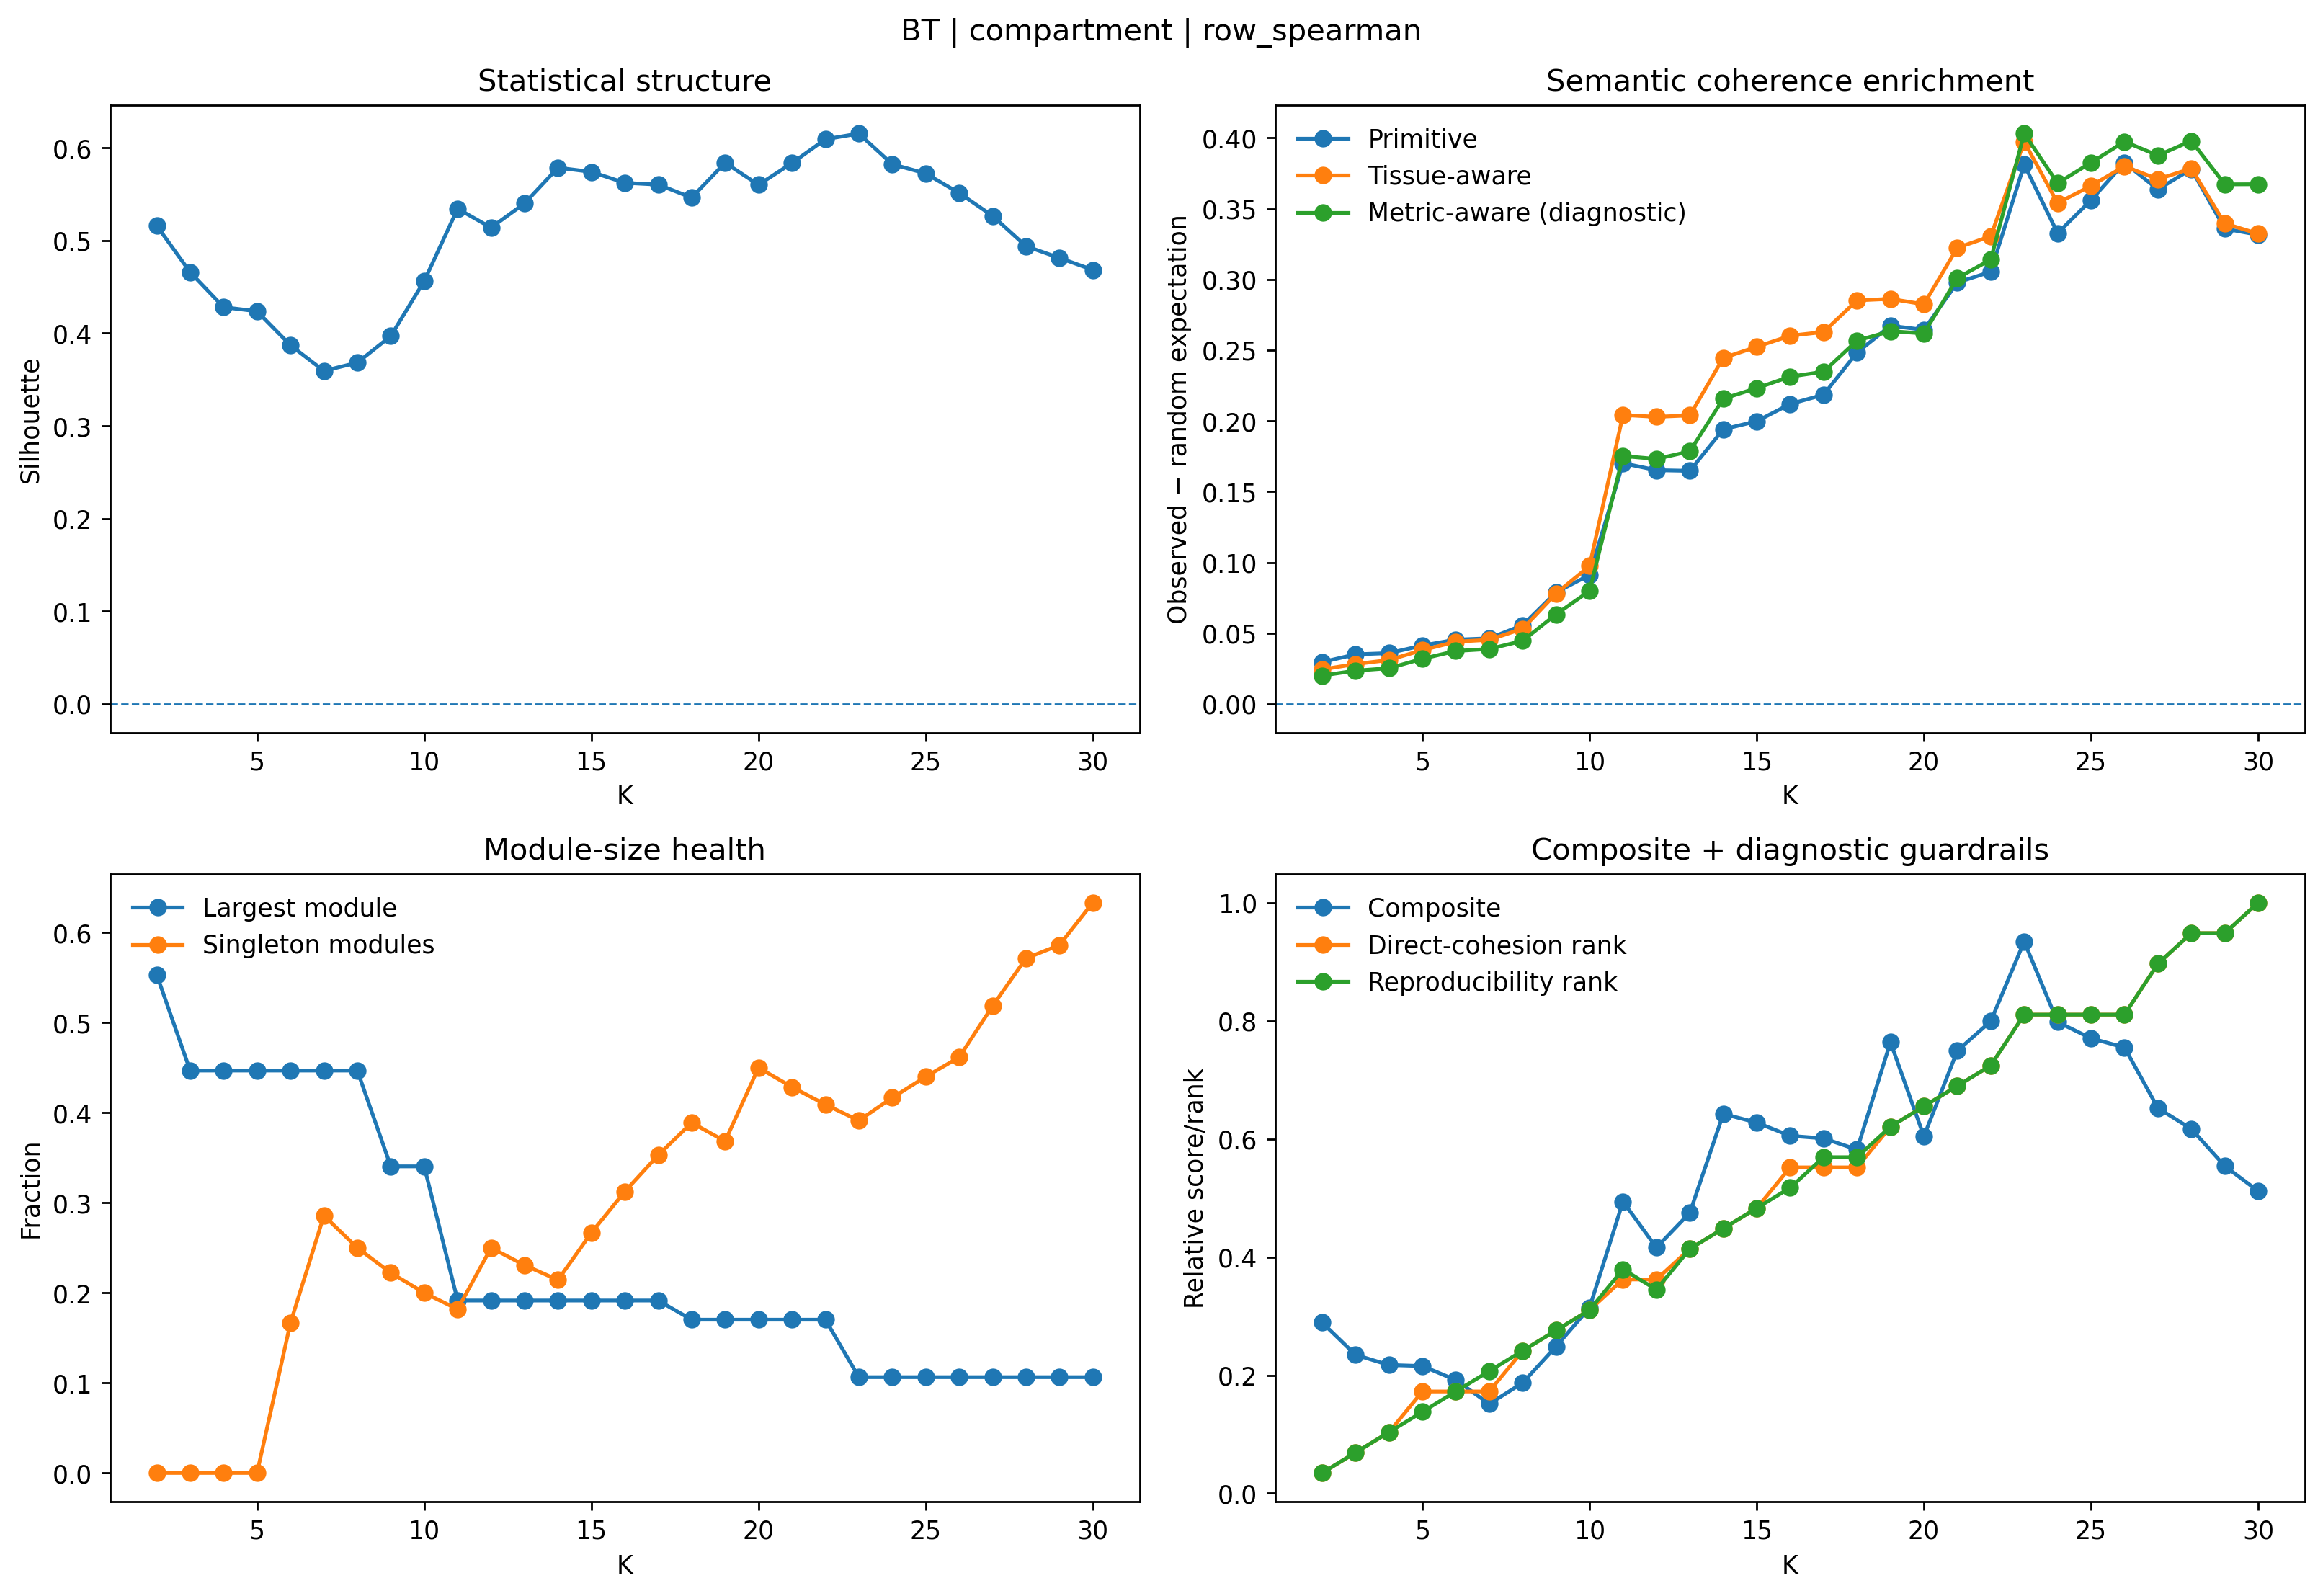


 02_semantic_silhouette.png


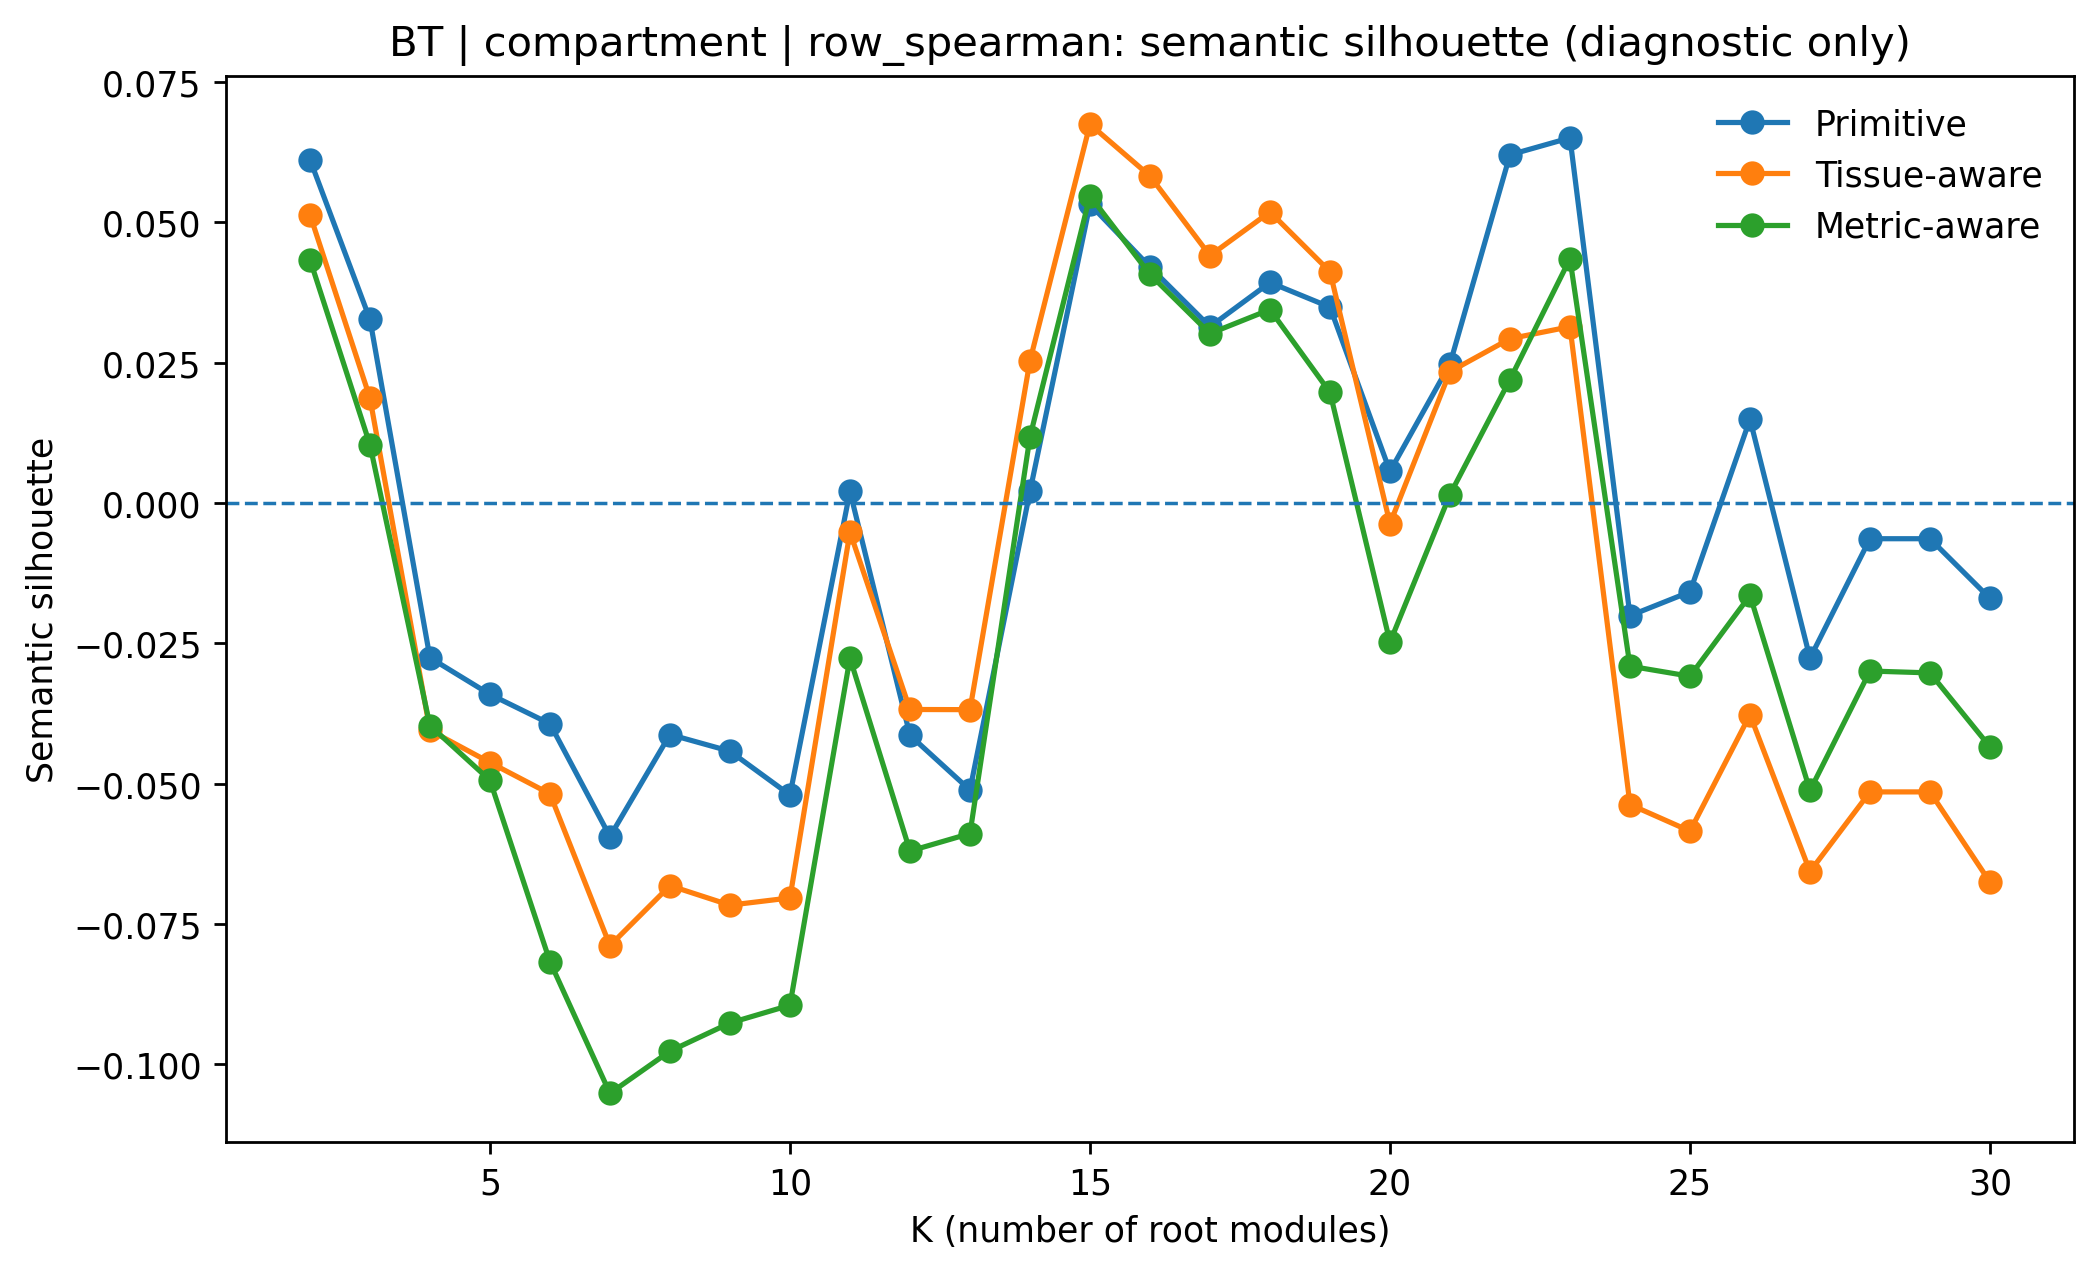


 07_within_module_consensus_rho.png


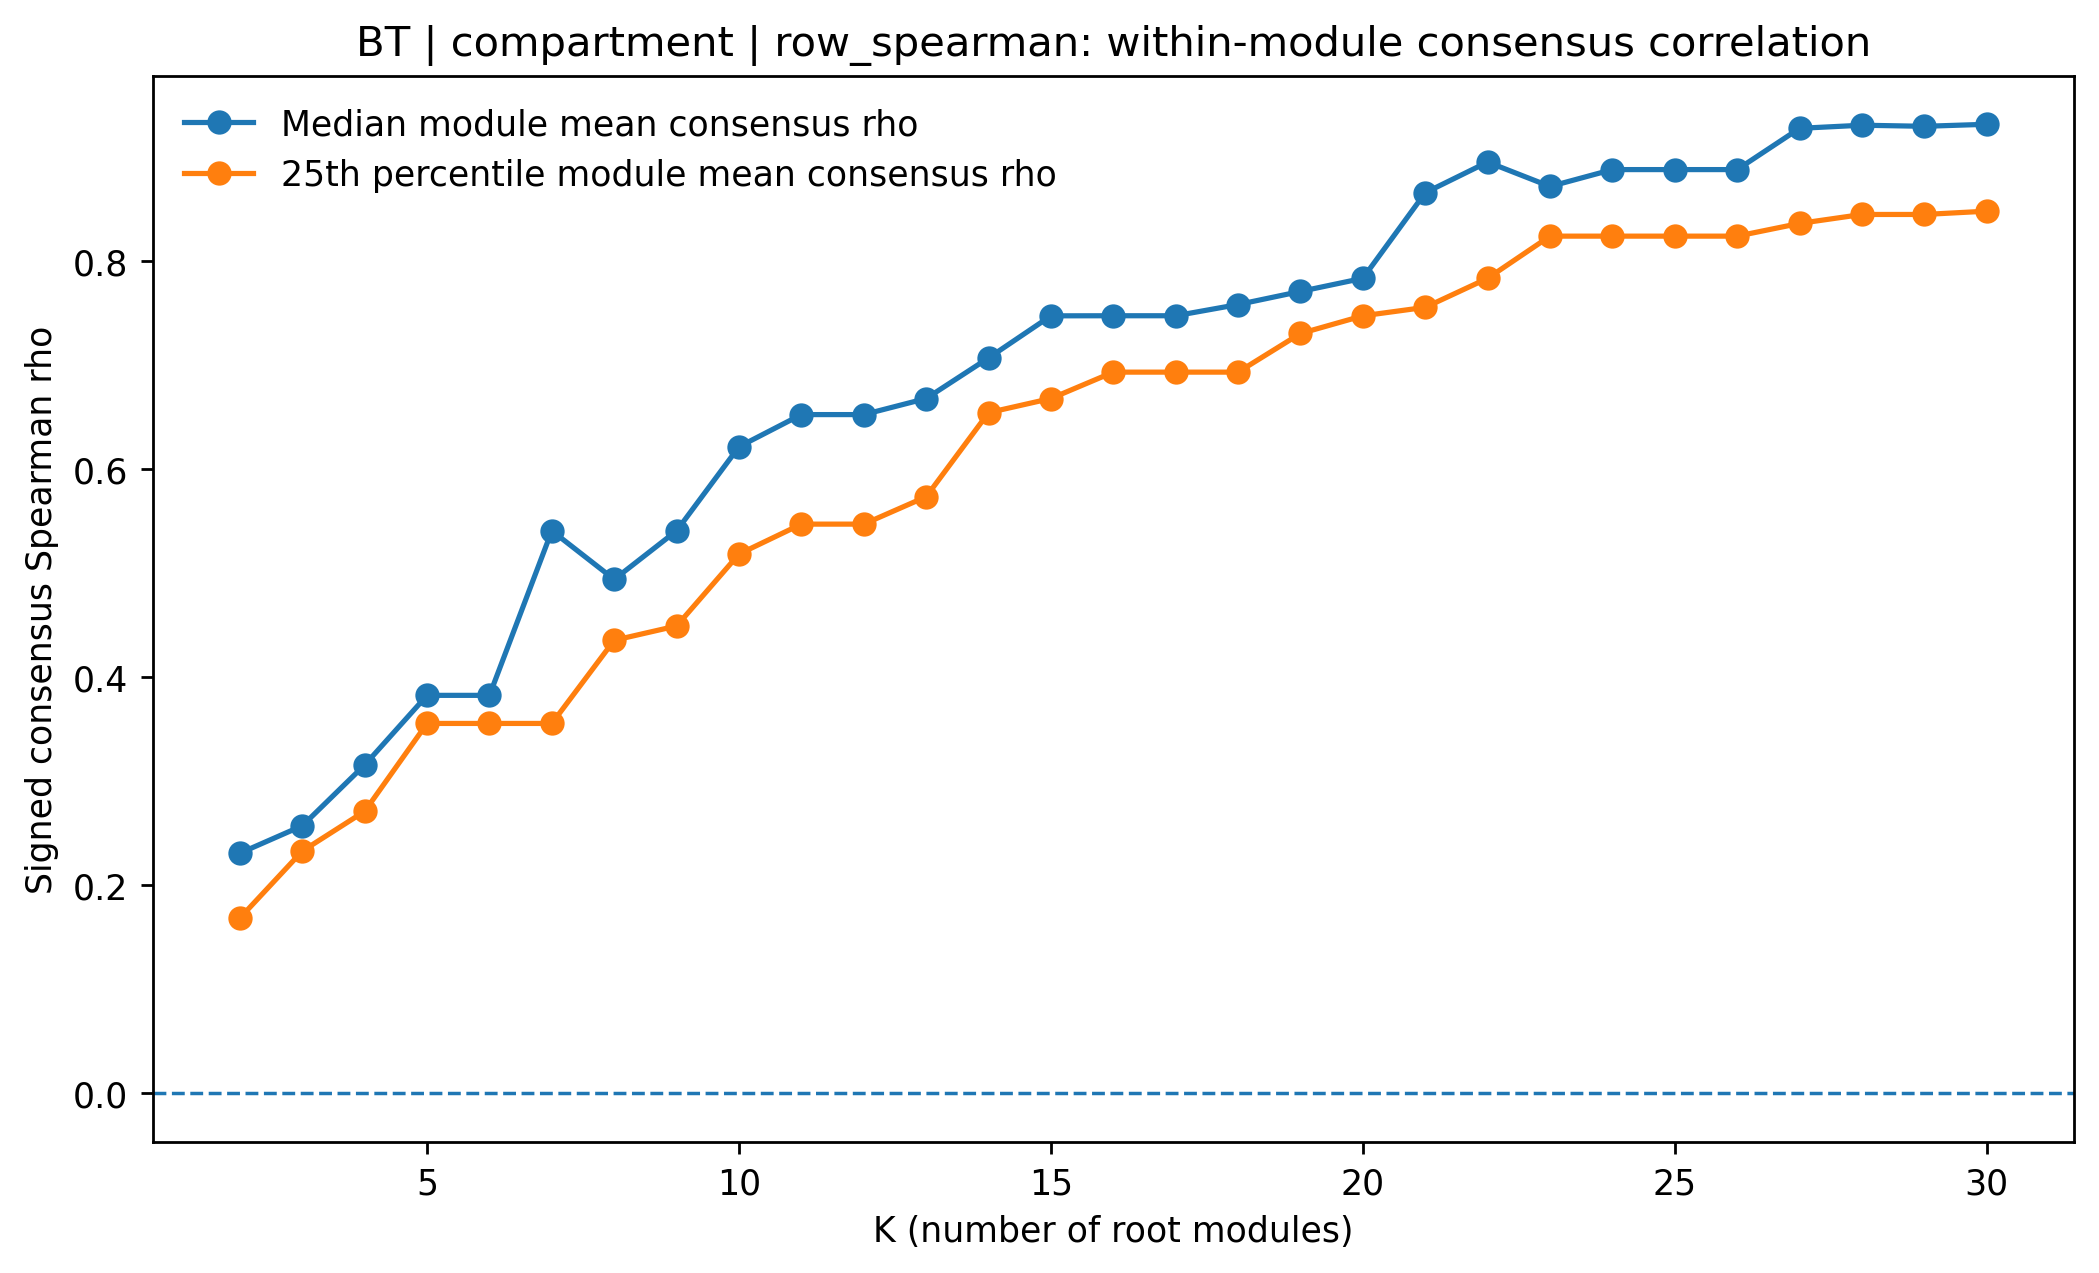


 08_cross_cohort_reproducibility.png


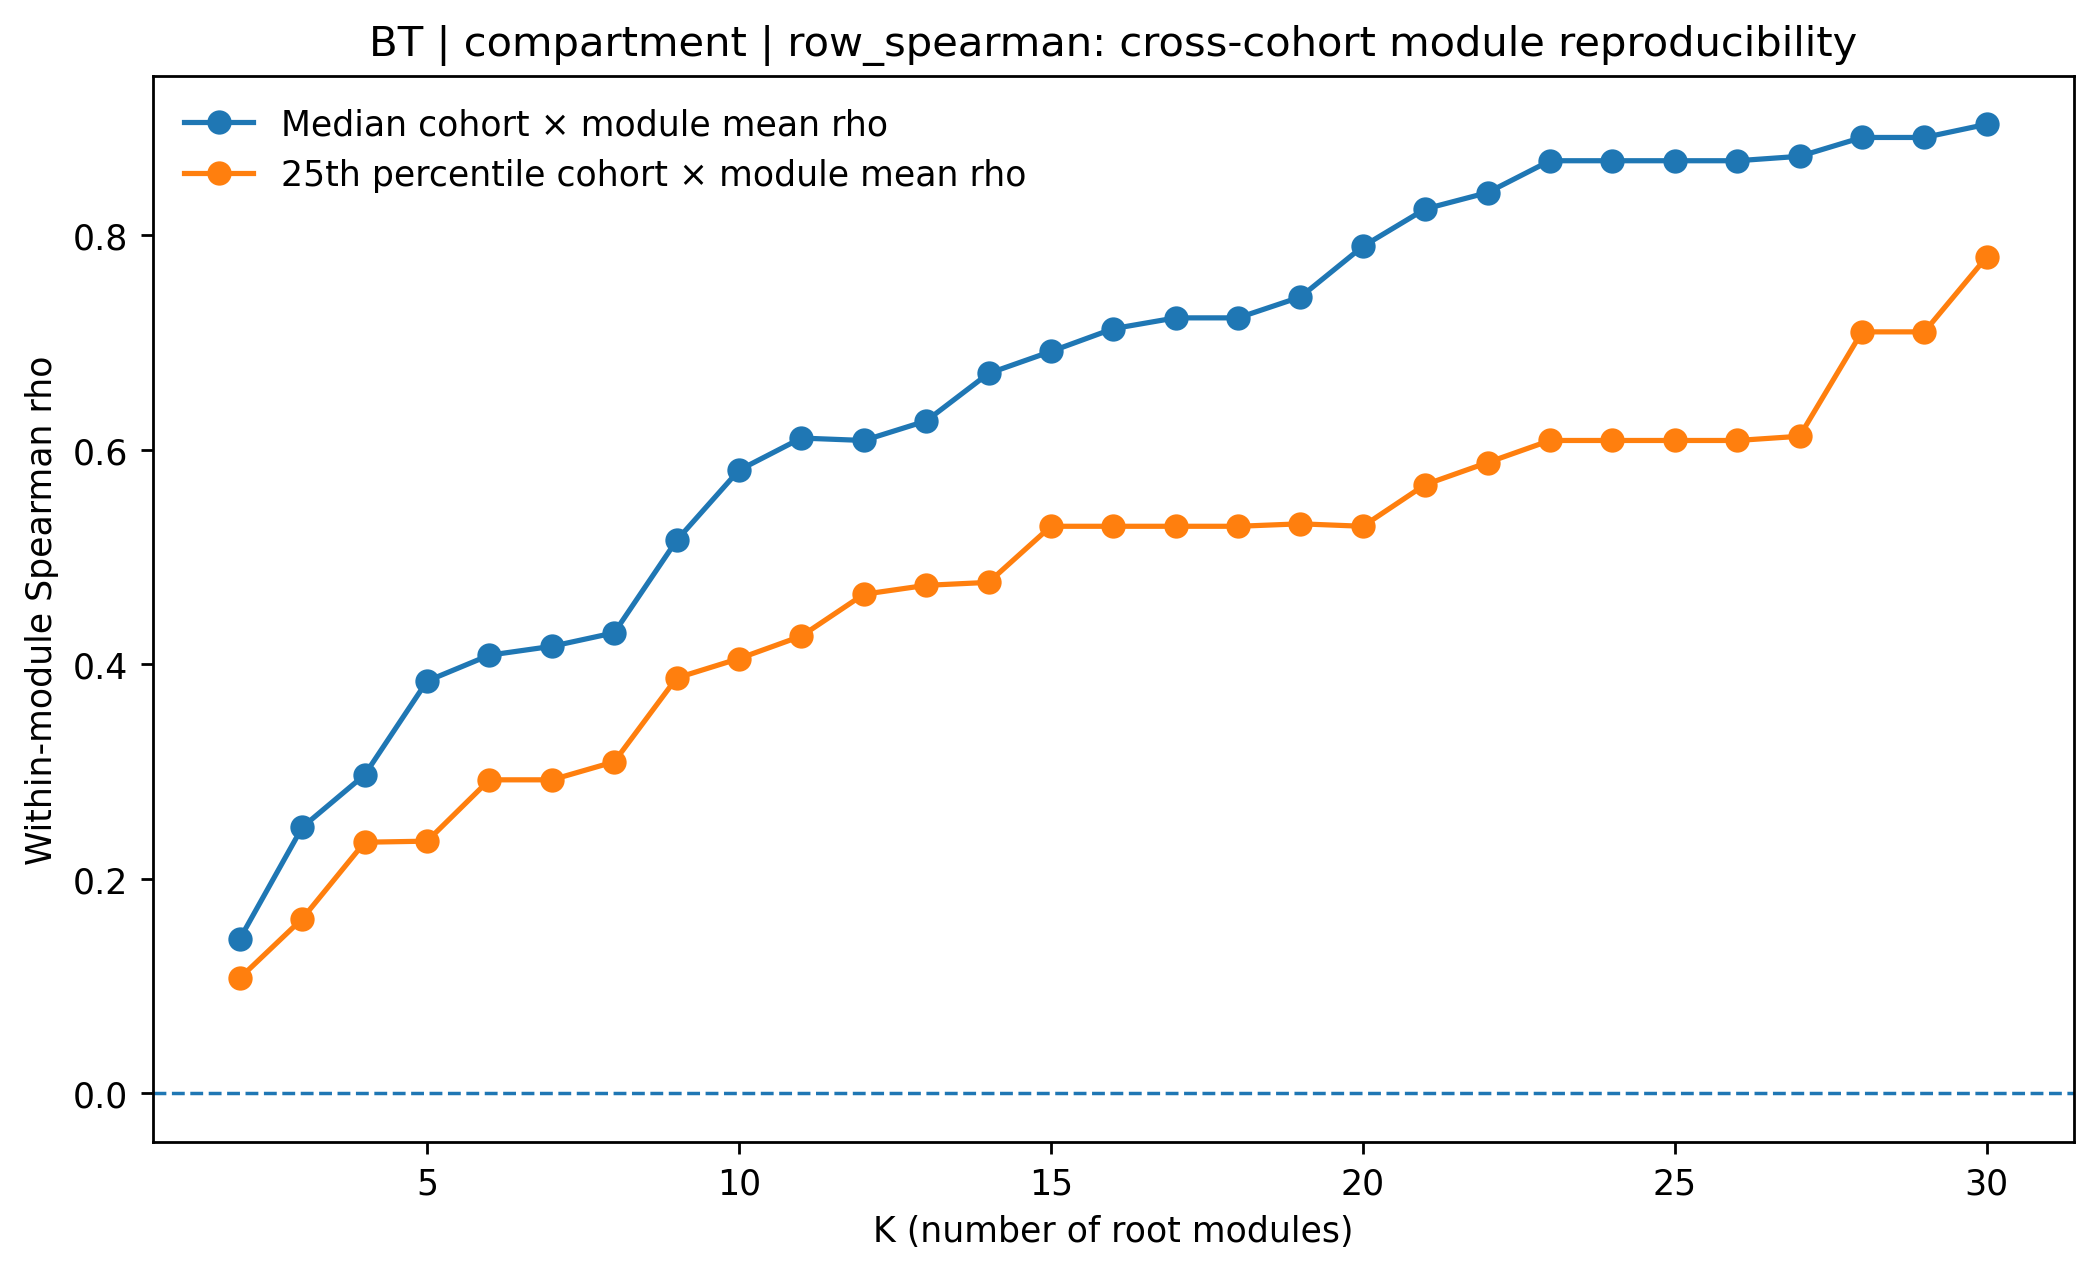


 09_k_composite_score.png


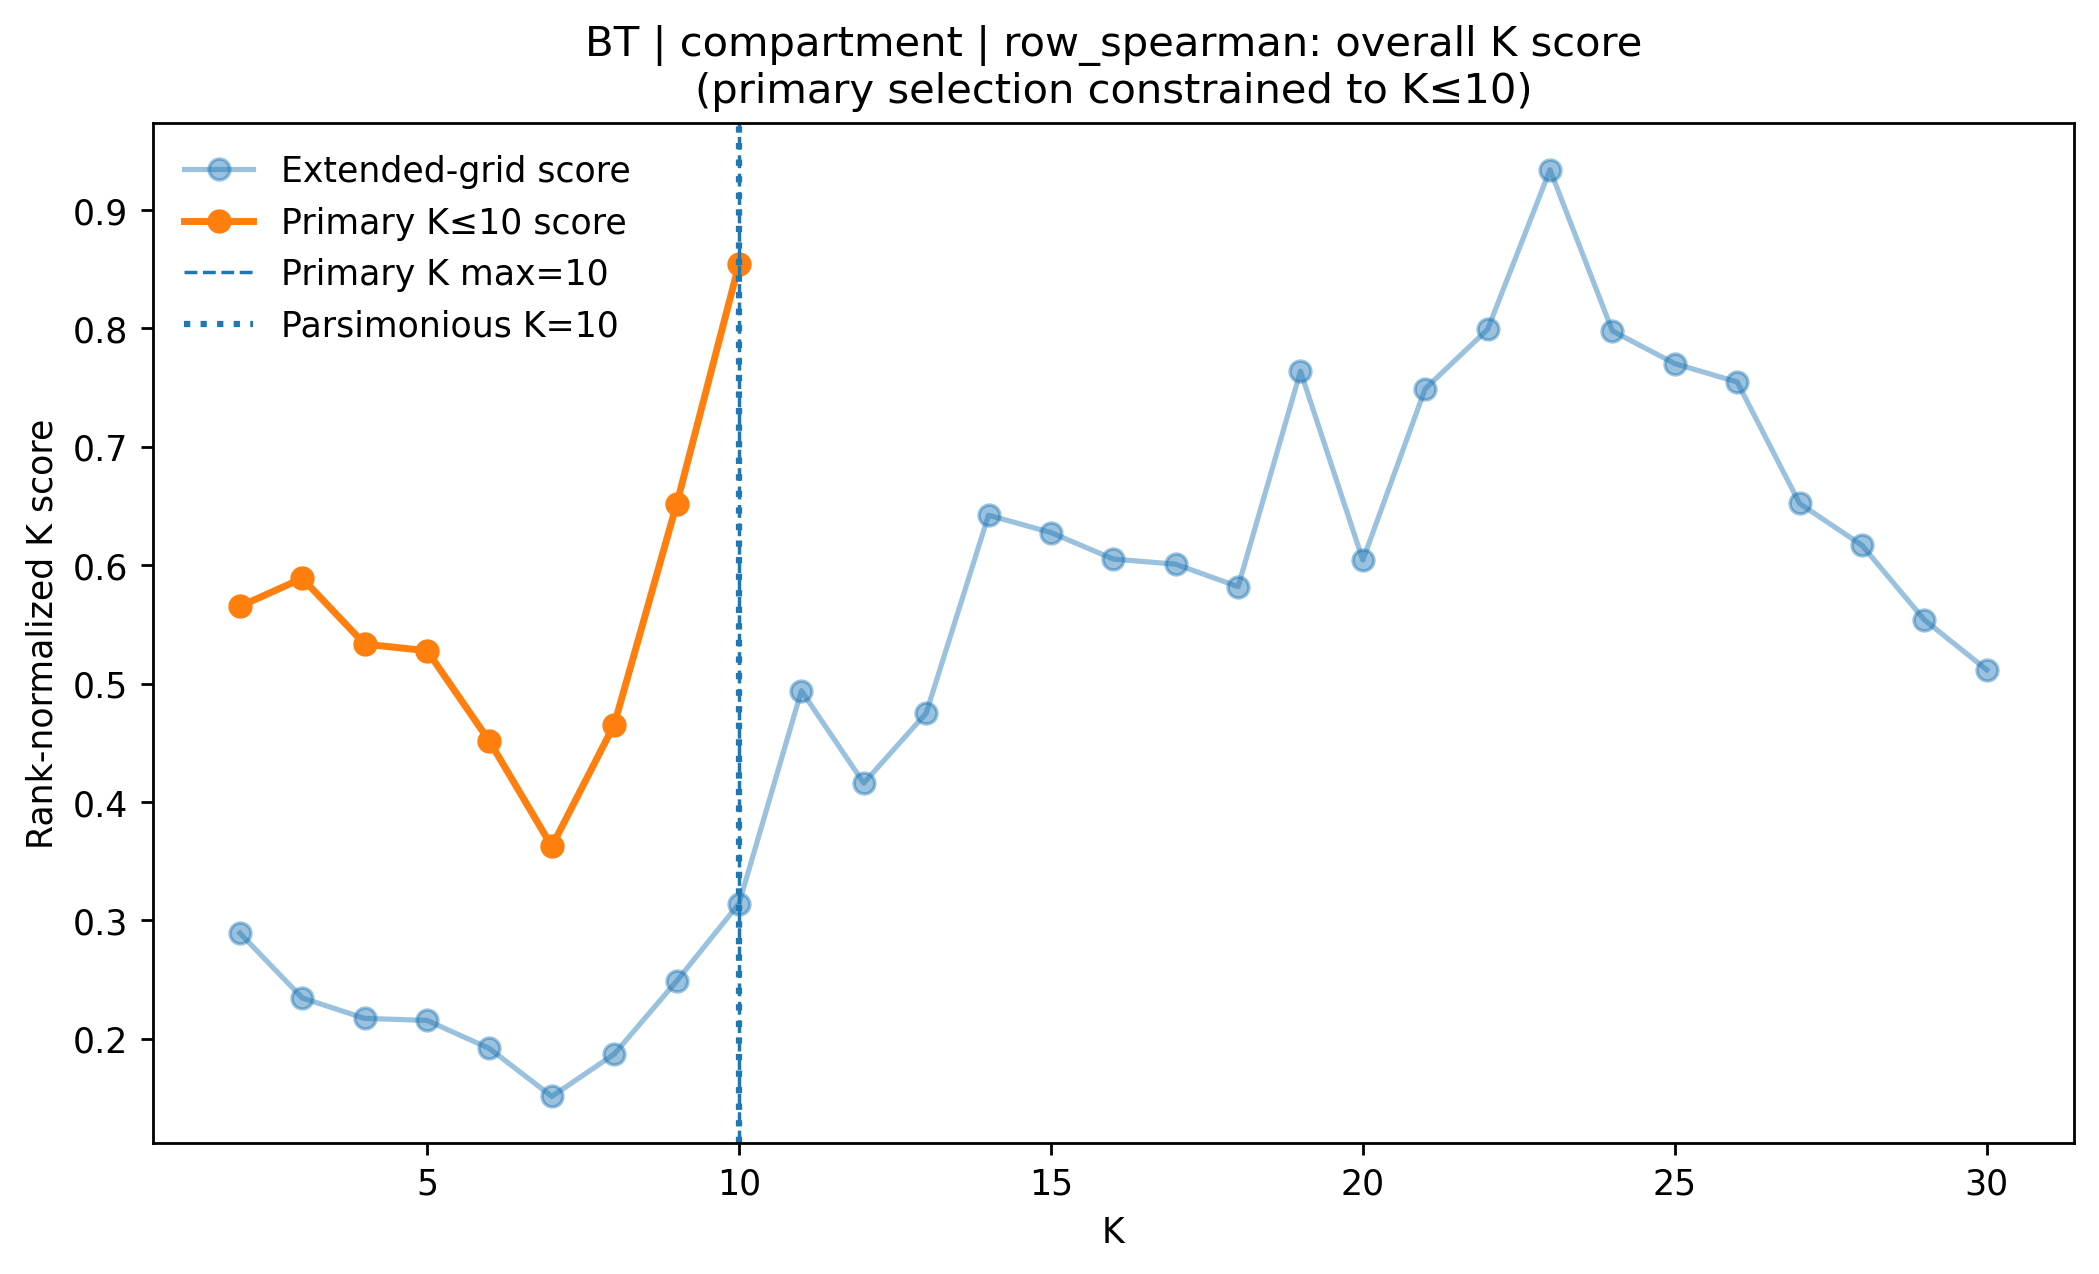


 11_primary_k_yield.png


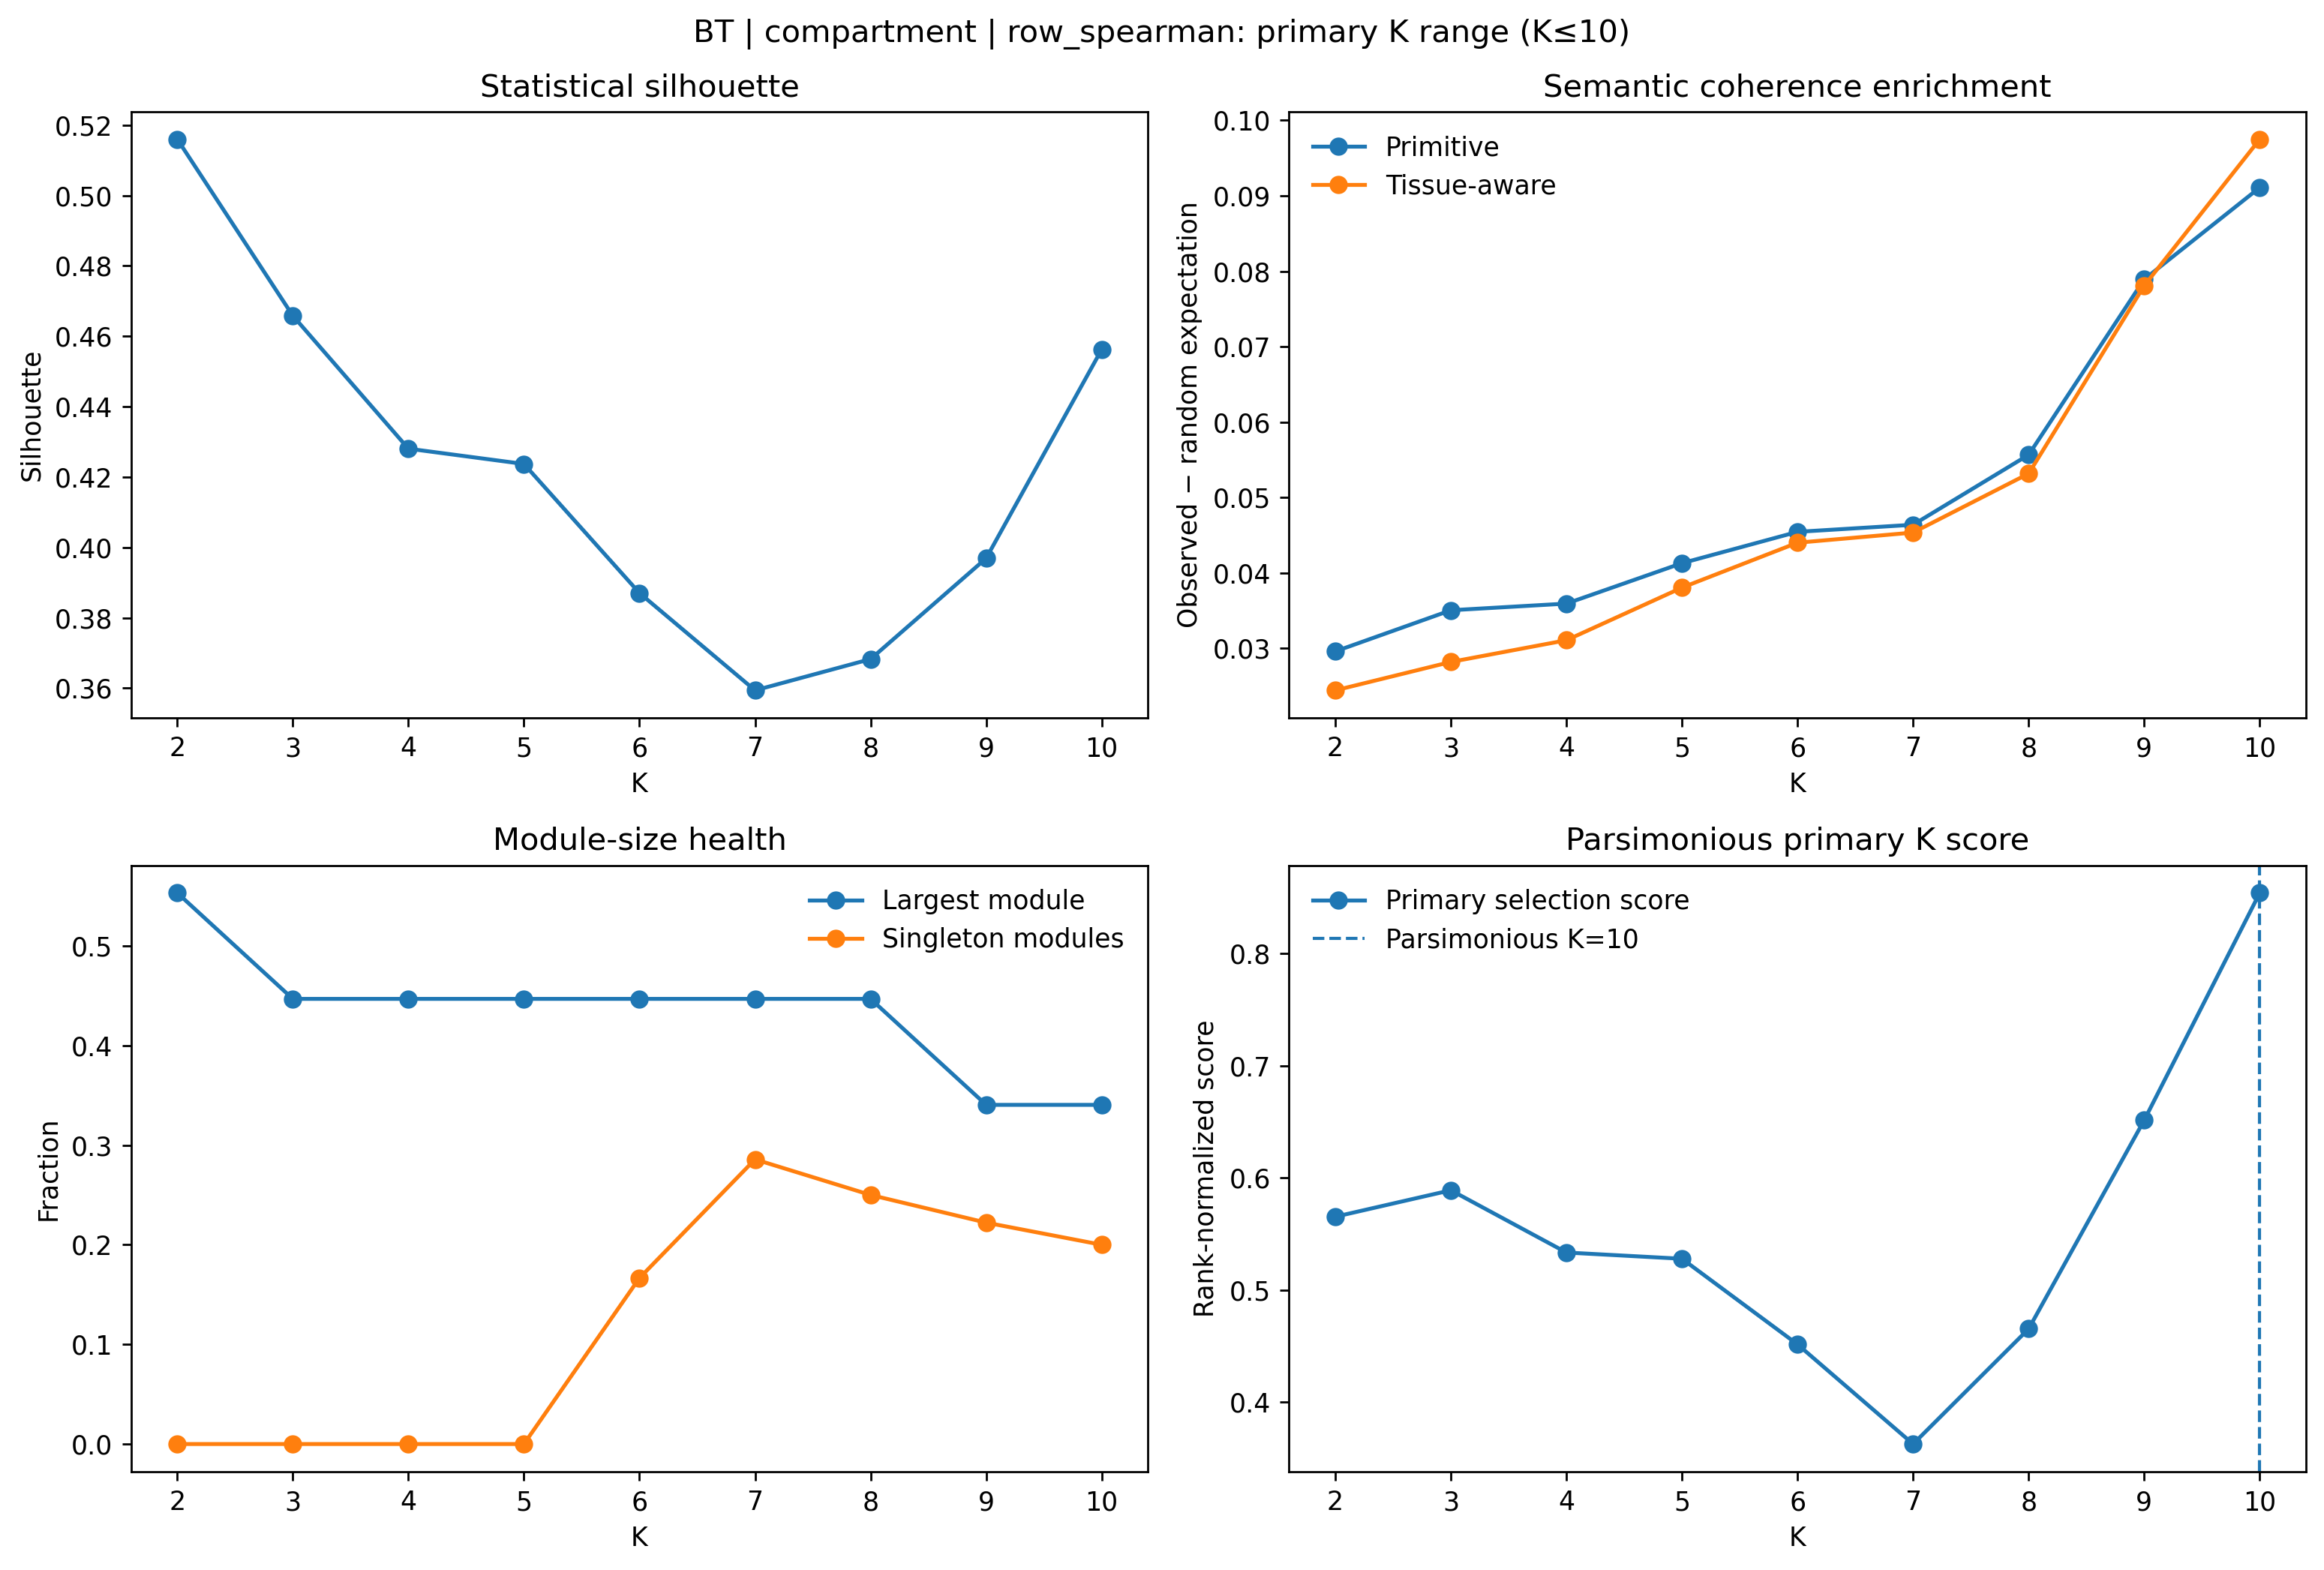


Top candidate-K heatmaps:
K10_consensus_heatmap.png


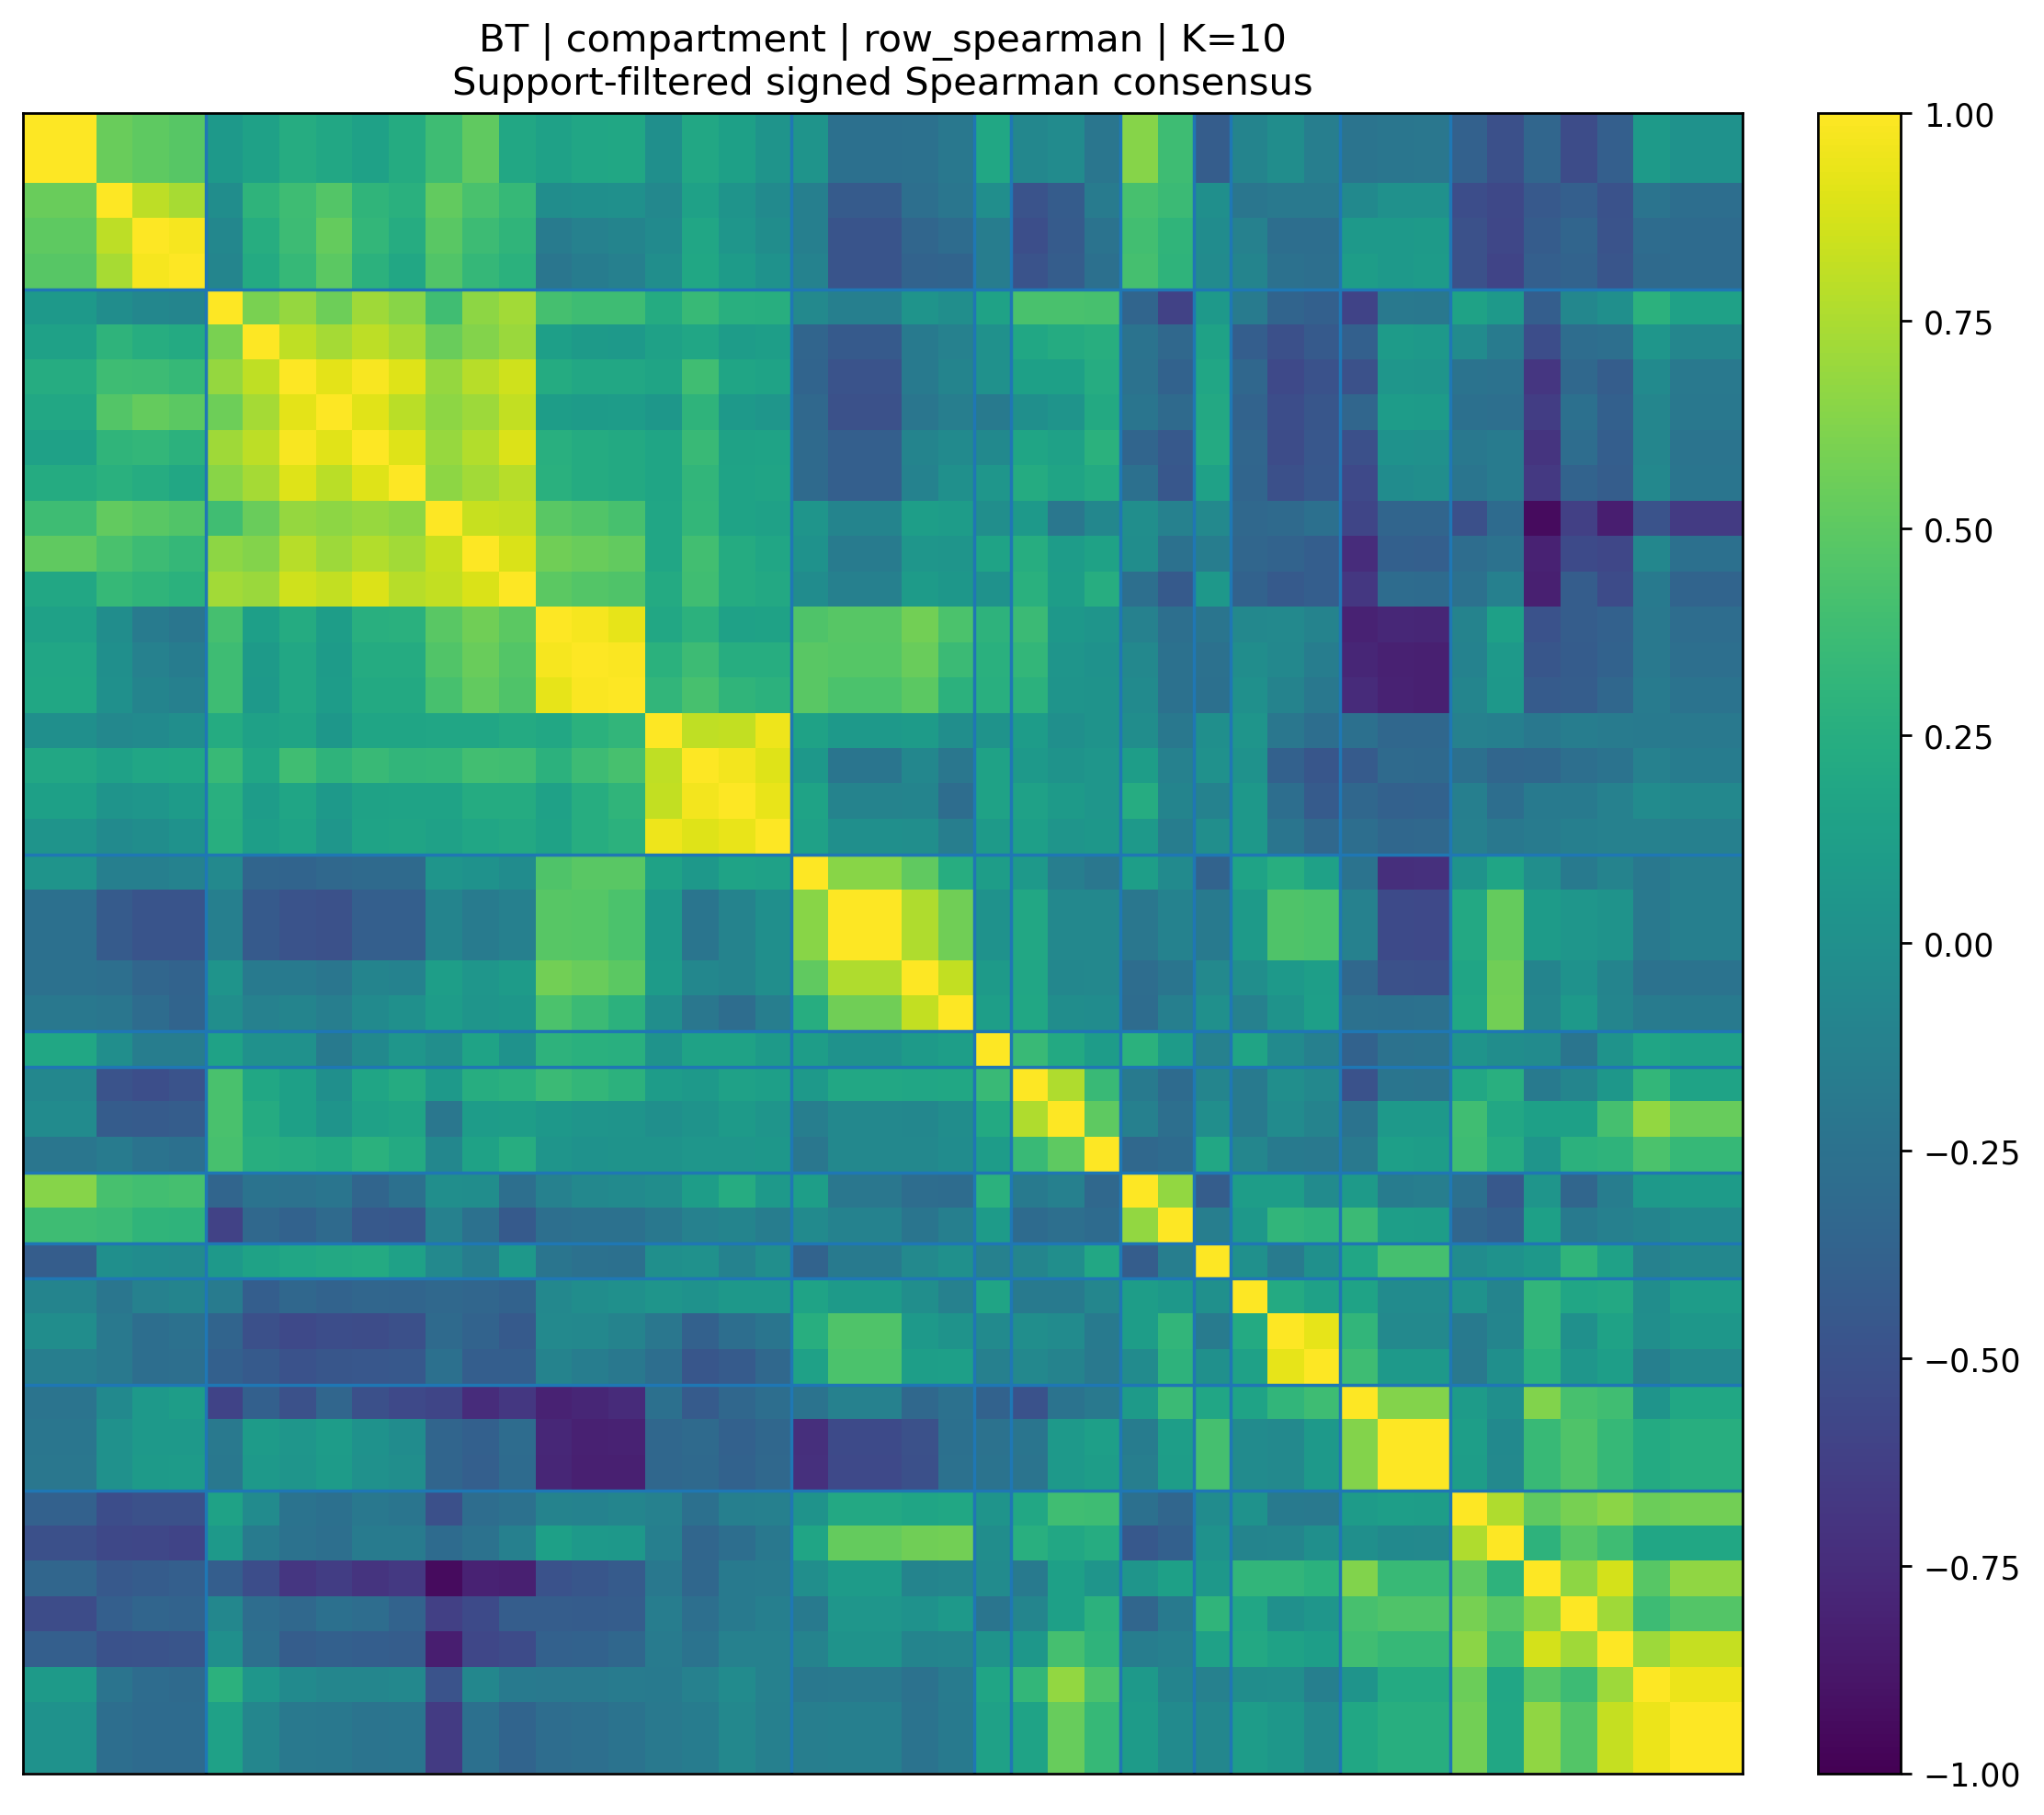

K22_consensus_heatmap.png


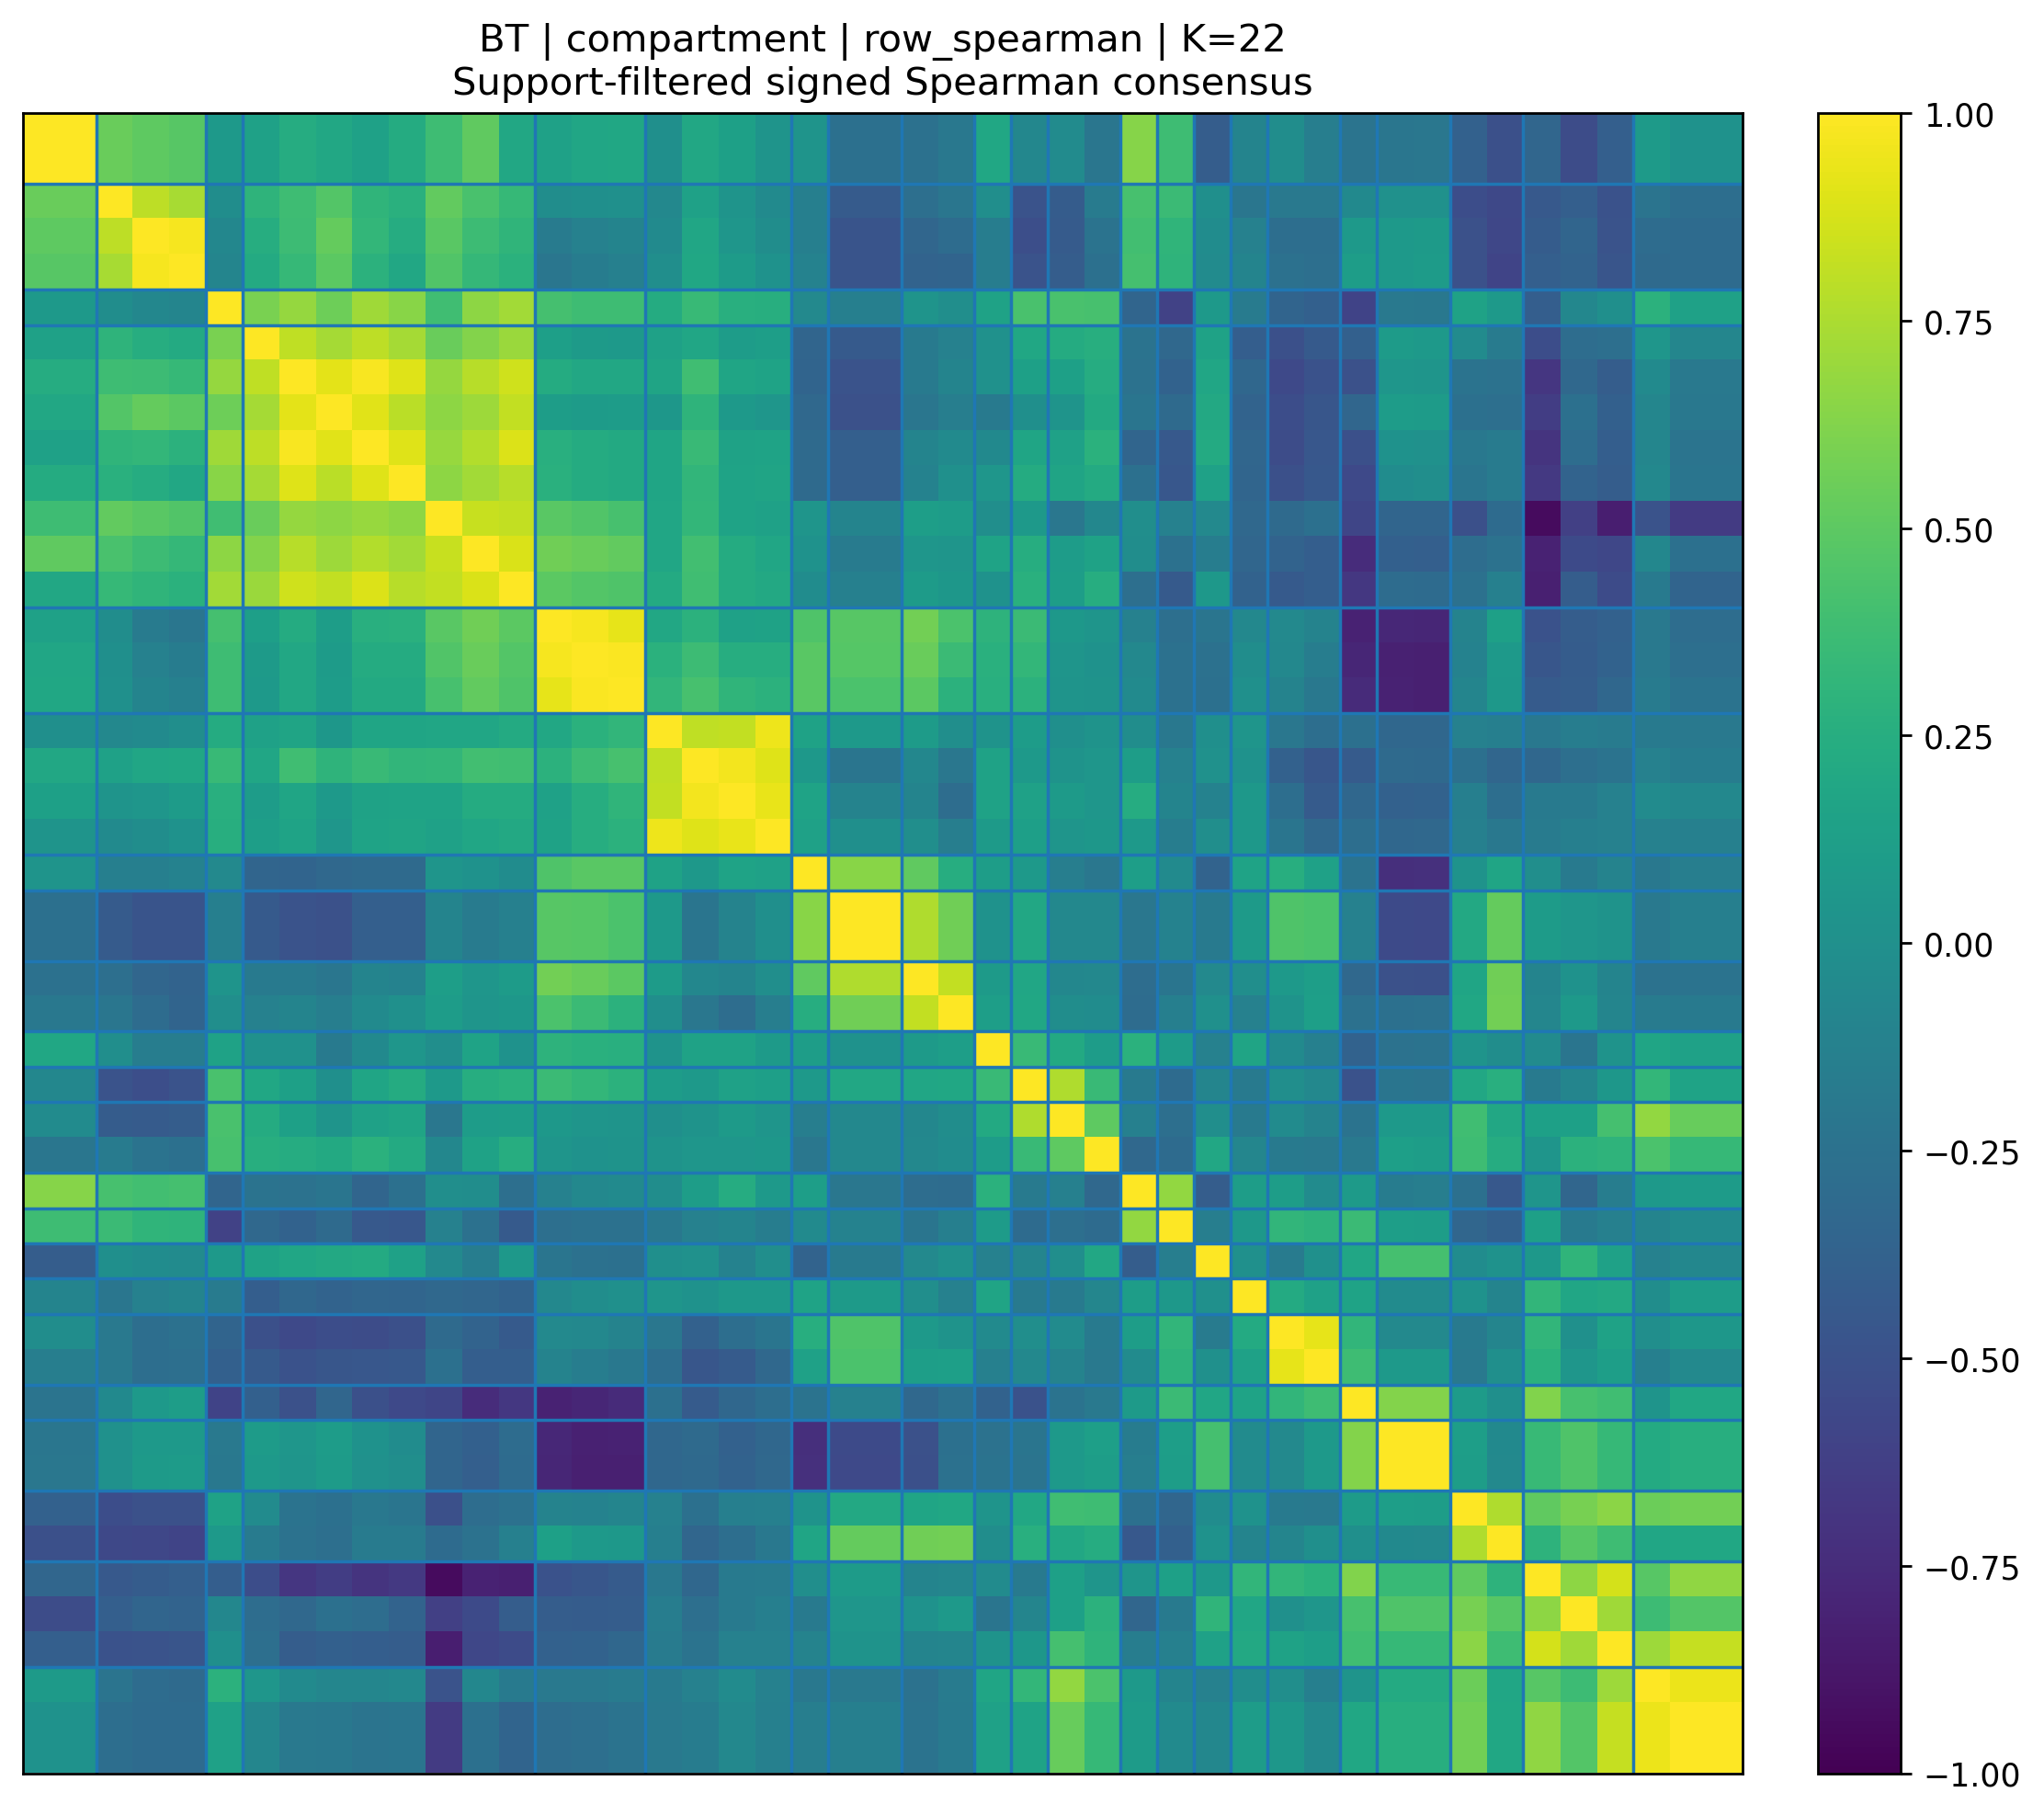

K23_consensus_heatmap.png


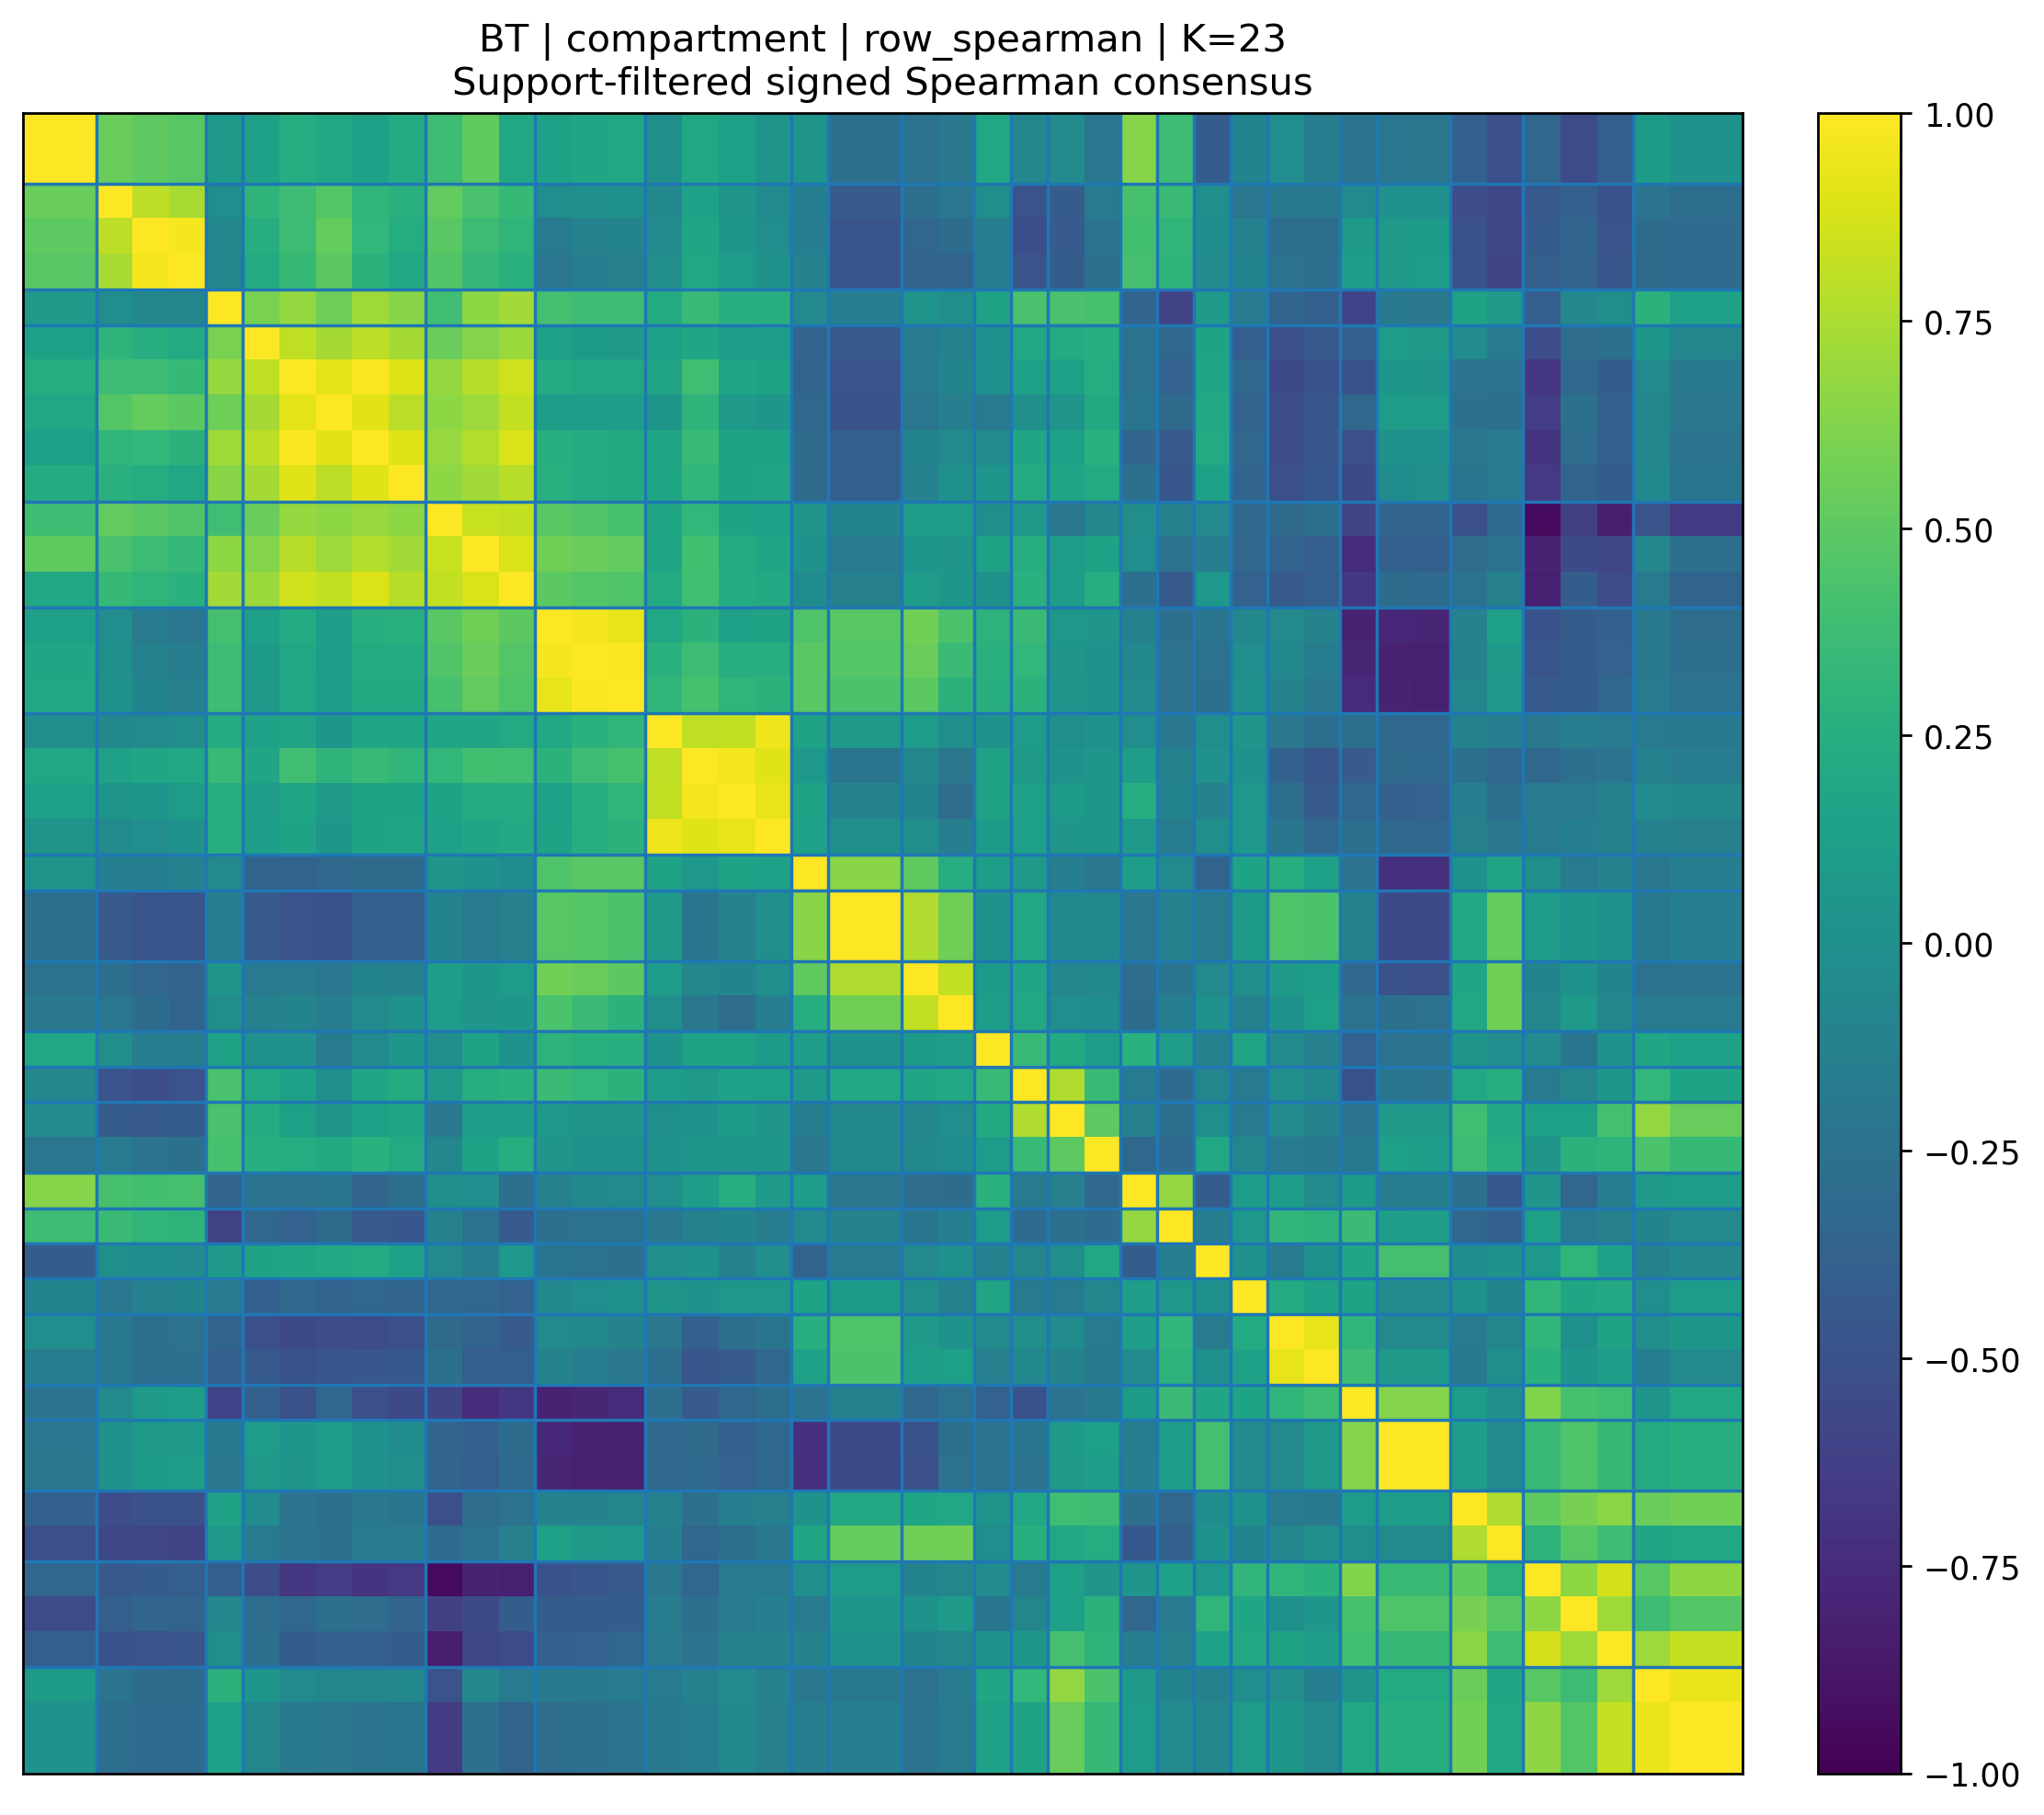

In [36]:
# ============================================================
# Cell 6 — Inspect one panel × prep root
# ============================================================

from IPython.display import Image, display

PANEL = "BT"
ROOT_NAME = "compartment"
MODE = PRIMARY_MODE

summary = b2.show_root_summary(
    review,
    panel=PANEL,
    root=ROOT_NAME,
    mode=MODE,
    top_n=15,
)
display(summary)

plot_dir = (
    OUT_ROOT / "roots" /
    f"{b2.safe_slug(PANEL)}__{b2.safe_slug(ROOT_NAME)}" /
    MODE / "plots"
)

for filename in [
    "00_k_review_dashboard.png",
    # "01_statistical_silhouette.png",
    "02_semantic_silhouette.png",
    # "03_semantic_coherence_raw_vs_null.png",
    # "04_semantic_coherence_enrichment.png",
    # "06_module_size_health.png",
    "07_within_module_consensus_rho.png",
    "08_cross_cohort_reproducibility.png",
    "09_k_composite_score.png",
    "11_primary_k_yield.png",
]:
    p = plot_dir / filename
    if p.exists():
        print("\n", filename)
        display(Image(filename=str(p)))

print("\nTop candidate-K heatmaps:")
for p in sorted((plot_dir / "top_k_heatmaps").glob("*.png")):
    print(p.name)
    display(Image(filename=str(p)))

In [30]:
# ============================================================
# Cell 7 — Compare row-Spearman primary vs direct-signed sensitivity
# ============================================================

mode_compare = review["recommendations"].copy()

cols = [
    "panel",
    "feature_source",
    "distance_mode",
    "n_features",
    "best_score_k",
    "recommended_parsimonious_k",
    "best_score",
    "recommended_stat_silhouette",
    "recommended_primitive_coherence_enrichment",
    "recommended_tissue_coherence_enrichment",
    "recommended_metric_coherence_enrichment",
    "recommended_max_cluster_fraction",
    "recommended_singleton_fraction",
    "recommended_q25_module_mean_consensus_rho",
    "recommended_median_module_fraction_positive_pairs",
    "recommended_passes_direct_cohesion_review",
    "recommended_cross_cohort_median_rho",
]
cols = [c for c in cols if c in mode_compare.columns]

display(
    mode_compare[cols]
    .sort_values(["panel", "feature_source", "distance_mode"])
    .reset_index(drop=True)
)

,panel,feature_source,distance_mode,n_features,best_score_k,recommended_parsimonious_k,best_score,recommended_stat_silhouette,recommended_primitive_coherence_enrichment,recommended_tissue_coherence_enrichment,recommended_metric_coherence_enrichment,recommended_max_cluster_fraction,recommended_singleton_fraction,recommended_q25_module_mean_consensus_rho,recommended_median_module_fraction_positive_pairs,recommended_passes_direct_cohesion_review,recommended_cross_cohort_median_rho
0,AR,AR_checkpoint_state,direct_signed,22,3,2,0.794444,0.636717,0.004297,0.013107,0.010316,0.727273,0.000000,0.407114,0.995833,True,0.442968
1,AR,AR_checkpoint_state,row_spearman,22,7,7,0.800000,0.658783,0.006139,0.050372,0.052424,0.500000,0.285714,0.523642,1.000000,True,0.650278
2,AR,AR_state,direct_signed,107,10,10,0.916667,0.302834,0.049072,0.046809,0.047197,0.542056,0.000000,0.434872,1.000000,True,0.461210
3,AR,AR_state,row_spearman,107,7,7,0.708333,0.518200,0.040582,0.048278,0.042200,0.457944,0.000000,0.409639,1.000000,True,0.425636
4,AR,compartment,direct_signed,37,10,9,0.916667,0.566231,0.277832,0.275266,0.285428,0.189189,0.222222,0.768230,1.000000,True,0.770332
5,AR,compartment,row_spearman,37,9,9,0.809722,0.711894,0.246939,0.237069,0.243273,0.243243,0.333333,0.766800,1.000000,True,0.757080
6,AR,compartment_state,direct_signed,93,8,8,0.872222,0.311868,0.109431,0.102622,0.106852,0.290323,0.000000,0.445656,1.000000,True,0.459184
7,AR,compartment_state,row_spearman,93,10,6,0.641667,0.498401,0.071149,0.052026,0.057453,0.451613,0.000000,0.378982,1.000000,True,0.444906
8,AR,phenotype_only,direct_signed,48,10,10,0.950000,0.458565,0.127399,0.113865,0.118545,0.250000,0.100000,0.619312,1.000000,True,0.611558
9,AR,phenotype_only,row_spearman,48,10,6,0.691667,0.668814,0.034963,0.024428,0.010830,0.604167,0.166667,0.335163,1.000000,True,0.533181


In [31]:
# ============================================================
# Additional cell — Focused primary K review (K <= 10)
# ============================================================

rr = review["root_results"][(PANEL, ROOT_NAME)]
res = rr["mode_results"][MODE]

kdiag = res["k_diagnostics"].copy()
primary_view = kdiag[
    kdiag["requested_k"] <= PRIMARY_SELECTION_K_MAX
].copy()

cols = [
    "requested_k",
    "k_primary_selection_score",
    "stat_silhouette",
    "primitive_coherence_enrichment",
    "tissue_aware_coherence_enrichment",
    "max_cluster_fraction",
    "singleton_fraction",
    "q25_module_mean_consensus_rho",
    "median_module_cohort_mean_rho",
    "within_primary_best_fraction",
    "passes_size_review",
]
cols = [c for c in cols if c in primary_view.columns]

display(
    primary_view[cols]
    .sort_values("requested_k")
    .reset_index(drop=True)
)

print("Primary recommendation:")
display(pd.DataFrame([b2.summarize_k_recommendation(kdiag)]))


,requested_k,k_primary_selection_score,stat_silhouette,primitive_coherence_enrichment,tissue_aware_coherence_enrichment,max_cluster_fraction,singleton_fraction,q25_module_mean_consensus_rho,median_module_cohort_mean_rho,within_primary_best_fraction,passes_size_review
0,2,0.561111,0.659456,0.022119,0.017223,0.623656,0.000000,0.233808,0.246312,False,False
1,3,0.583333,0.566568,0.030914,0.022943,0.559140,0.000000,0.285371,0.251487,True,False
2,4,0.555556,0.532419,0.031321,0.022396,0.559140,0.000000,0.324336,0.325449,False,False
3,5,0.561111,0.531399,0.043322,0.029630,0.559140,0.000000,0.354257,0.377900,False,False
4,6,0.584722,0.498401,0.071149,0.052026,0.451613,0.000000,0.378982,0.444906,True,True
5,7,0.576389,0.464455,0.073897,0.053950,0.451613,0.142857,0.378982,0.444906,False,True
6,8,0.490278,0.437095,0.073974,0.053841,0.451613,0.250000,0.408889,0.459877,False,True
7,9,0.445833,0.434783,0.074230,0.053713,0.451613,0.333333,0.408889,0.459877,False,False
8,10,0.641667,0.449587,0.143775,0.137961,0.247312,0.300000,0.433831,0.501707,True,False


Primary recommendation:


,panel,feature_source,distance_mode,n_features,extended_grid_best_k,extended_grid_best_score,primary_selection_k_max,best_score_k,best_score,recommended_parsimonious_k,...,recommended_primitive_coherence_enrichment,recommended_tissue_coherence_enrichment,recommended_metric_coherence_enrichment,recommended_max_cluster_fraction,recommended_singleton_fraction,recommended_q25_module_mean_consensus_rho,recommended_median_module_fraction_positive_pairs,recommended_passes_direct_cohesion_review,recommended_cross_cohort_median_rho,recommended_fraction_module_cohort_positive
0,AR,compartment_state,row_spearman,93,26,0.746121,10,10,0.641667,6,...,0.071149,0.052026,0.057453,0.451613,0.0,0.378982,1.0,True,0.444906,1.0


Saved: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/manual_heatmaps/BT__compartment/row_spearman/K10_annotated_consensus_heatmap.png
Saved: /projects/ovcare/users/nikolay_alabi/immuno/stage2_root_meta_modules_v1/stage2b2_root_k_review_v3/manual_heatmaps/BT__compartment/row_spearman/K10_ordered_membership.csv


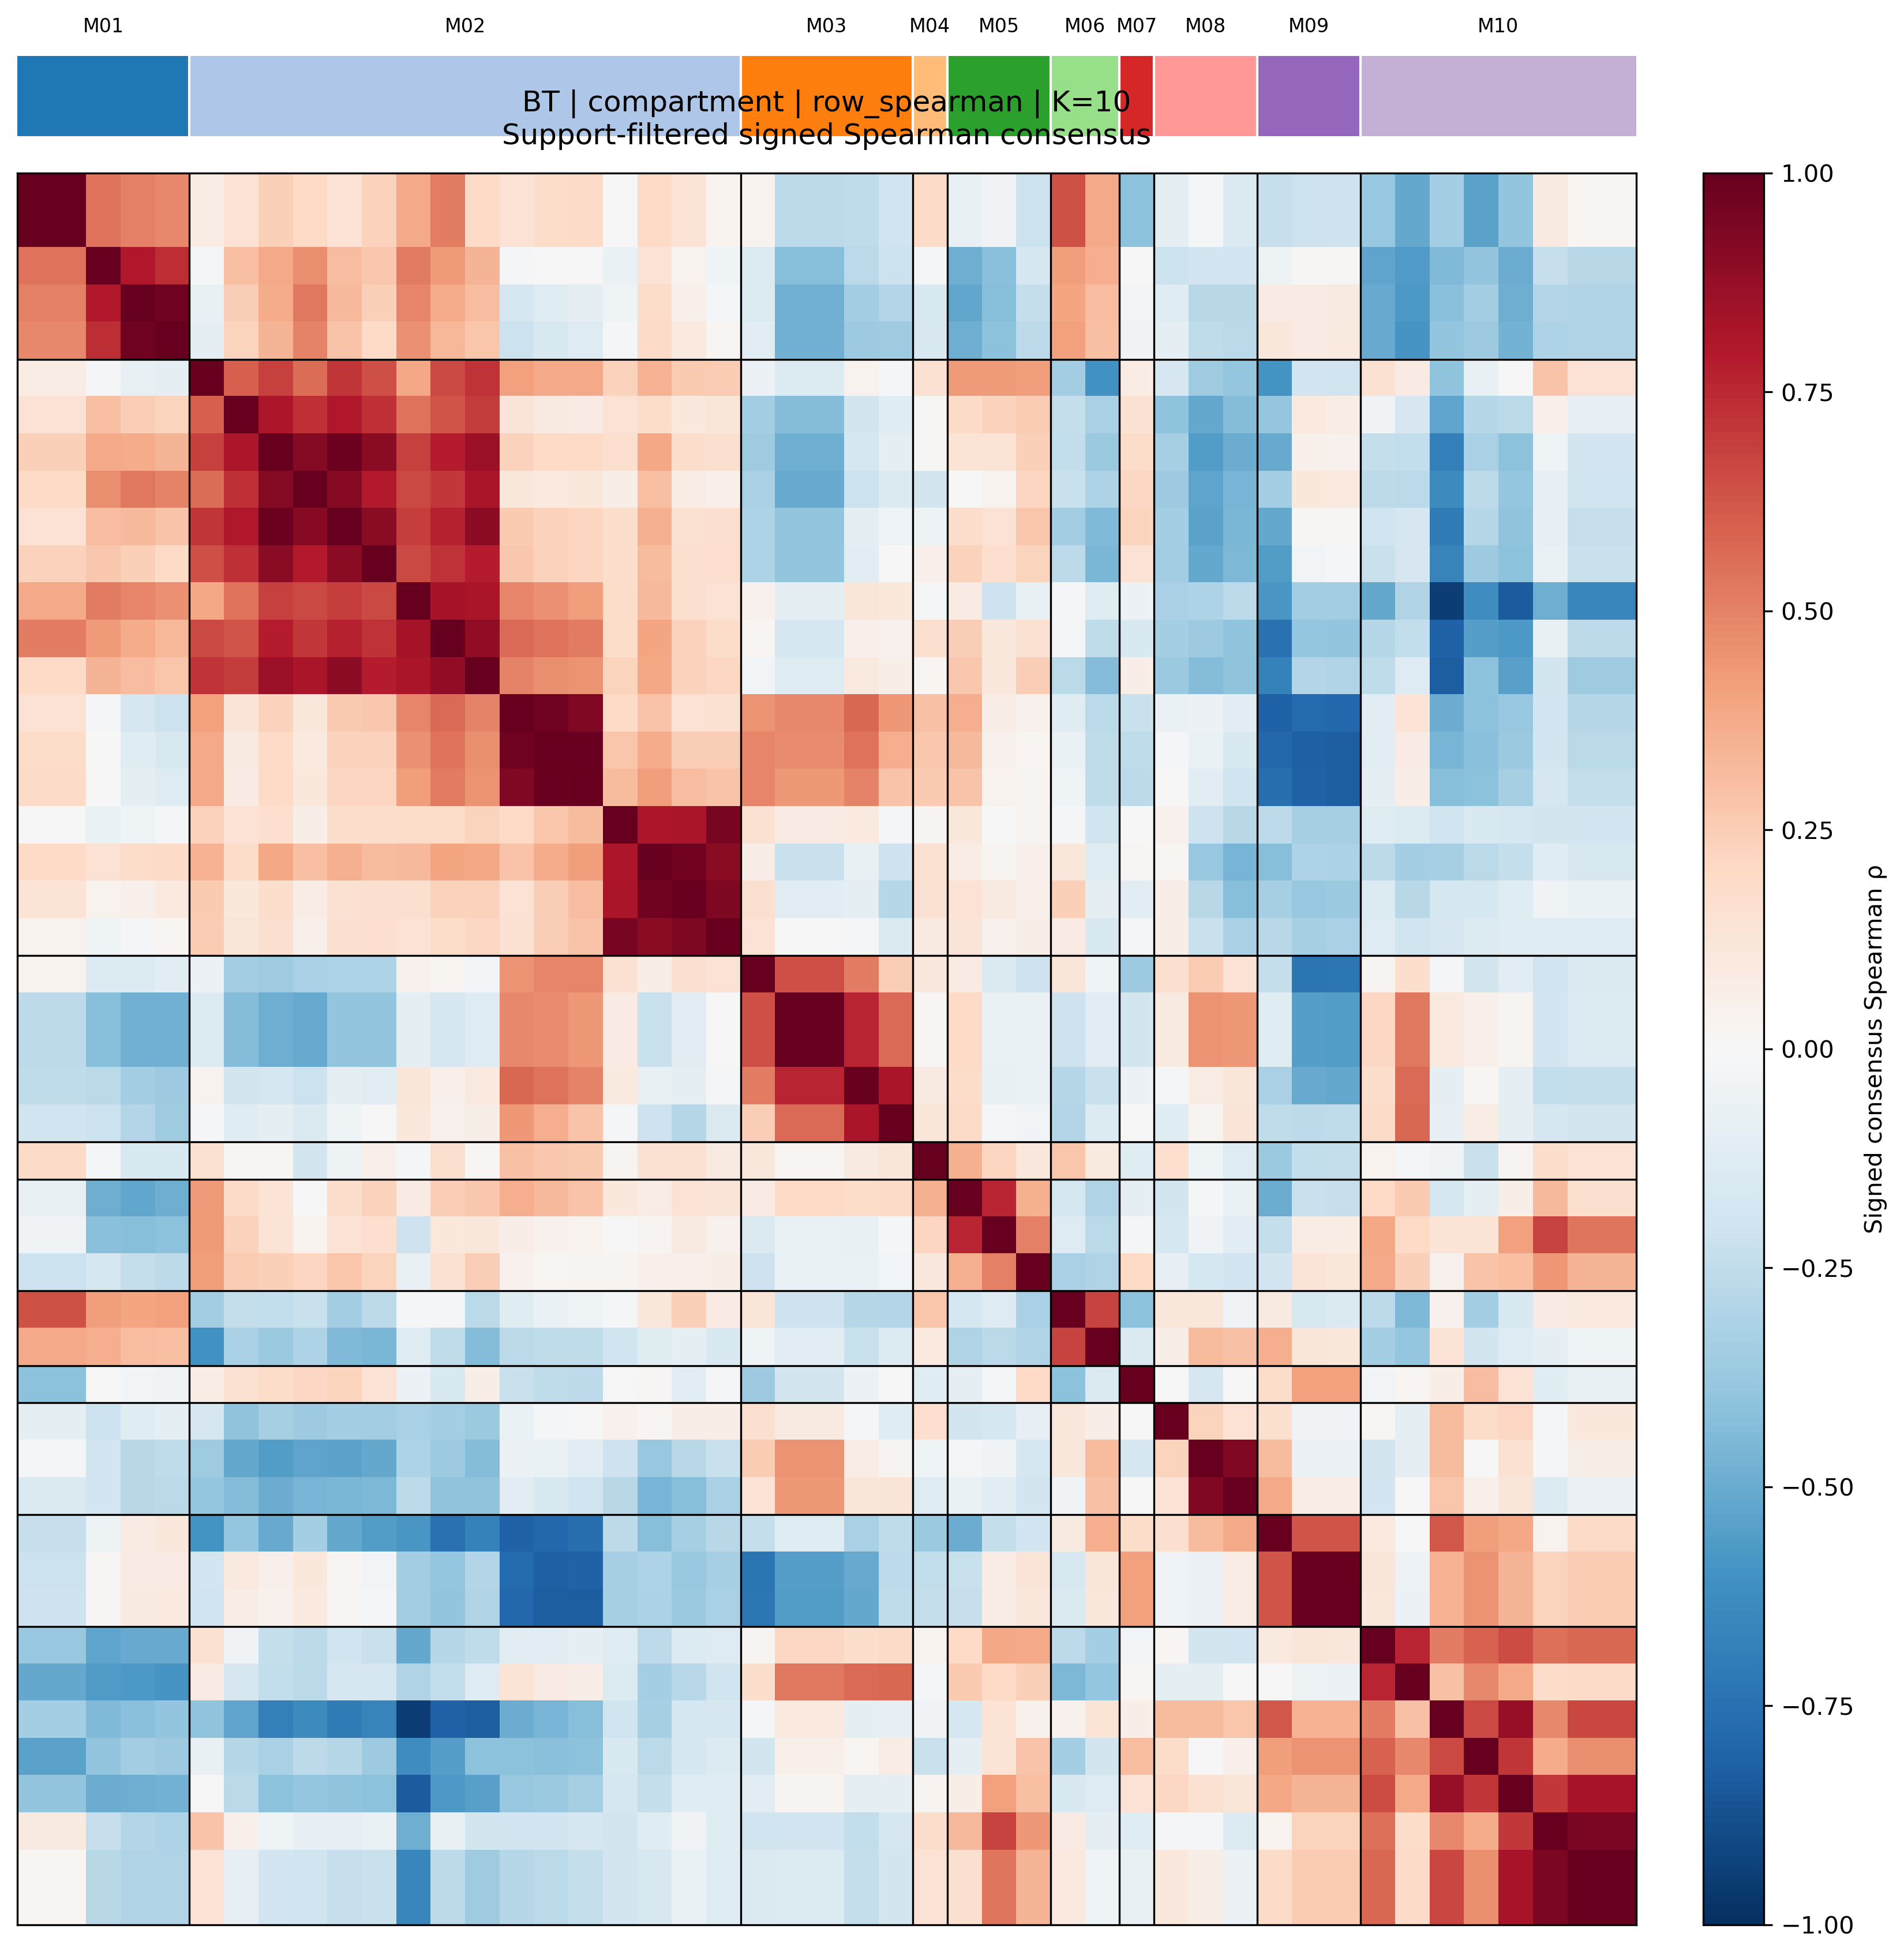

,feature_uid,raw_cluster_id,module_num_ordered,module_label
0,S2B1_BT_a43bb154ccf9e783,5,1,M01
1,S2B1_BT_c7f94d1b97c528d4,5,1,M01
2,S2B1_BT_3e360268c6aa1a83,5,1,M01
3,S2B1_BT_2fe3350f5e45f77f,5,1,M01
4,S2B1_BT_ab4b4c73a611849f,5,1,M01
5,S2B1_BT_154e1289a9cc7109,4,2,M02
6,S2B1_BT_e1648f12eb05ccfc,4,2,M02
7,S2B1_BT_87cbc788c4dfffde,4,2,M02
8,S2B1_BT_a4738fa5e7c4ecd8,4,2,M02
9,S2B1_BT_555aed69f2f405ec,4,2,M02


In [40]:
# ============================================================
# Additional cell — Annotated red/blue consensus heatmap for any chosen K
# ============================================================

# Change these four values to inspect any panel/root/geometry/K.
HEATMAP_PANEL = "BT"
HEATMAP_ROOT = "compartment"
HEATMAP_MODE = PRIMARY_MODE
HEATMAP_K = 10

rr = review["root_results"][(HEATMAP_PANEL, HEATMAP_ROOT)]
res = rr["mode_results"][HEATMAP_MODE]
consensus = rr["inputs"]["consensus"]

heatmap_dir = (
    OUT_ROOT / "manual_heatmaps" /
    f"{b2.safe_slug(HEATMAP_PANEL)}__{b2.safe_slug(HEATMAP_ROOT)}" /
    HEATMAP_MODE
)
heatmap_dir.mkdir(parents=True, exist_ok=True)

heatmap_path = heatmap_dir / f"K{HEATMAP_K:02d}_annotated_consensus_heatmap.png"
membership_path = heatmap_dir / f"K{HEATMAP_K:02d}_ordered_membership.csv"

ordered_membership = b2.plot_annotated_k_heatmap(
    consensus,
    res,
    HEATMAP_K,
    heatmap_path,
    panel=HEATMAP_PANEL,
    root=HEATMAP_ROOT,
    distance_mode=HEATMAP_MODE,
    show_feature_labels=False,  # set True for a labelled supplementary version
)

ordered_membership.to_csv(membership_path, index=False)

print("Saved:", heatmap_path)
print("Saved:", membership_path)
display(Image(filename=str(heatmap_path)))
display(ordered_membership)


In [ ]:
# ============================================================
# Cell 8 — OPTIONAL: freeze final K after reviewing every root
# ============================================================

# Leave empty until the diagnostic review is complete.
FINAL_K = {
    # ("AR", "phenotype_only"): 6,
    # ("AR", "AR_state"): 7,
    # ("AR", "AR_checkpoint_state"): 3,
    # ("AR", "compartment"): 9,
    # ("AR", "compartment_state"): 6,
    # ("BT", "phenotype_only"): 4,
    # ("BT", "compartment"): ...,
}

if FINAL_K:
    frozen = b2.save_manual_k_selections(
        OUT_ROOT / "stage2b2_manual_k_review_template.csv",
        FINAL_K,
        OUT_ROOT / "stage2b2_final_k_selections.csv",
    )
    display(frozen)
    print("Saved:", OUT_ROOT / "stage2b2_final_k_selections.csv")
else:
    print("FINAL_K is empty — nothing frozen yet.")